# Mobile Network Traffic Forecasting

**Name:** Hikma Hamza  
**Project:** Comparative Analysis of Sequential Models for Mobile Network Traffic Forecasting

### Project Plan
This project investigates one-step-ahead mobile network traffic forecasting using the Milan telecommunications dataset. The data will be processed efficiently using chunk-based loading and memory optimization, followed by exploratory analysis of traffic patterns across geographical areas. Three sequential models — **MLP, 1D CNN, and LSTM** — will be trained and compared using MAE, MAPE, and RMSE. Their performance, training time, and ability to capture different traffic patterns will then be analyzed across selected geographical areas.

In [4]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
#Import

import os
import gc
import glob
import time
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Flatten,
    Dense,
    Conv1D,
    MaxPooling1D,
    LSTM
)
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU: []


In [6]:
#Project path

PROJECT_PATH = "/content/drive/MyDrive/mobile_traffic_forecasting"

DATA_PATH = os.path.join(PROJECT_PATH, "data")
RAW_PATH = os.path.join(DATA_PATH, "raw")
PROCESSED_PATH = os.path.join(DATA_PATH, "processed")

FIGURES_PATH = os.path.join(PROJECT_PATH, "figures")
RESULTS_PATH = os.path.join(PROJECT_PATH, "results")
MODELS_PATH = os.path.join(PROJECT_PATH, "models")
NOTEBOOKS_PATH = os.path.join(PROJECT_PATH, "notebooks")

for path in [
    DATA_PATH,
    RAW_PATH,
    PROCESSED_PATH,
    FIGURES_PATH,
    RESULTS_PATH,
    MODELS_PATH,
    NOTEBOOKS_PATH
]:
    os.makedirs(path, exist_ok=True)

print("Project path:", PROJECT_PATH)

Project path: /content/drive/MyDrive/mobile_traffic_forecasting


In [7]:
#Dataset configuration

COLUMNS = [
    "square_id",
    "timestamp",
    "country_code",
    "sms_in",
    "sms_out",
    "call_in",
    "call_out",
    "internet"
]

OPTIMIZED_DTYPES = {
    "square_id": "int32",
    "timestamp": "int64",
    "country_code": "int32",
    "sms_in": "float32",
    "sms_out": "float32",
    "call_in": "float32",
    "call_out": "float32",
    "internet": "float32"
}

print("Dataset columns defined.")

Dataset columns defined.


In [8]:
#VERIFY THE 21 FILES

raw_files = sorted(
    glob.glob(
        os.path.join(RAW_PATH, "*.txt")
    )
)

print("=" * 60)
print("RETAINED RAW FILES")
print("=" * 60)

print("Number of files:", len(raw_files))

for i, file_path in enumerate(raw_files, start=1):
    print(f"{i:02d}. {os.path.basename(file_path)}")

RETAINED RAW FILES
Number of files: 21
01. sms-call-internet-mi-2013-11-01.txt
02. sms-call-internet-mi-2013-11-02.txt
03. sms-call-internet-mi-2013-11-03.txt
04. sms-call-internet-mi-2013-11-04.txt
05. sms-call-internet-mi-2013-11-05.txt
06. sms-call-internet-mi-2013-11-06.txt
07. sms-call-internet-mi-2013-11-07.txt
08. sms-call-internet-mi-2013-11-08.txt
09. sms-call-internet-mi-2013-11-09.txt
10. sms-call-internet-mi-2013-11-10.txt
11. sms-call-internet-mi-2013-11-11.txt
12. sms-call-internet-mi-2013-11-12.txt
13. sms-call-internet-mi-2013-11-13.txt
14. sms-call-internet-mi-2013-11-14.txt
15. sms-call-internet-mi-2013-12-16.txt
16. sms-call-internet-mi-2013-12-17.txt
17. sms-call-internet-mi-2013-12-18.txt
18. sms-call-internet-mi-2013-12-19.txt
19. sms-call-internet-mi-2013-12-20.txt
20. sms-call-internet-mi-2013-12-21.txt
21. sms-call-internet-mi-2013-12-22.txt


In [9]:
#MEMORY MANAGEMENT

sample_file = raw_files[0]

# BEFORE OPTIMISATION
df_before = pd.read_csv(
    sample_file,
    sep="\t",
    header=None,
    names=COLUMNS,
    nrows=100000
)

memory_before = (
    df_before.memory_usage(deep=True).sum()
    / (1024 ** 2)
)

# AFTER OPTIMISATION
df_after = pd.read_csv(
    sample_file,
    sep="\t",
    header=None,
    names=COLUMNS,
    nrows=100000,
    dtype=OPTIMIZED_DTYPES
)

memory_after = (
    df_after.memory_usage(deep=True).sum()
    / (1024 ** 2)
)

memory_reduction = (
    (memory_before - memory_after)
    / memory_before
) * 100

print(f"Memory before optimisation: {memory_before:.2f} MB")
print(f"Memory after optimisation:  {memory_after:.2f} MB")
print(f"Memory reduction:            {memory_reduction:.2f}%")

del df_before, df_after
gc.collect()

Memory before optimisation: 6.10 MB
Memory after optimisation:  3.43 MB
Memory reduction:            43.75%


0

In [10]:
#PROCESS THE 21 RETAINED FILES

processed_daily = []

for i, file_path in enumerate(raw_files, start=1):

    filename = os.path.basename(file_path)

    print(
        f"[{i}/{len(raw_files)}] Processing: {filename}"
    )

    chunks = []

    for chunk in pd.read_csv(
        file_path,
        sep="\t",
        header=None,
        names=COLUMNS,
        usecols=[
            "square_id",
            "timestamp",
            "internet"
        ],
        dtype={
            "square_id": "int32",
            "timestamp": "int64",
            "internet": "float32"
        },
        chunksize=100000
    ):

        grouped = (
            chunk
            .groupby(
                ["square_id", "timestamp"],
                as_index=False
            )["internet"]
            .sum(min_count=1)
        )

        chunks.append(grouped)

    daily = pd.concat(
        chunks,
        ignore_index=True
    )

    daily = (
        daily
        .groupby(
            ["square_id", "timestamp"],
            as_index=False
        )["internet"]
        .sum(min_count=1)
    )

    daily["datetime"] = pd.to_datetime(
        daily["timestamp"],
        unit="ms"
    )

    processed_daily.append(daily)

    del chunks, daily
    gc.collect()

print("\nProcessing complete.")

[1/21] Processing: sms-call-internet-mi-2013-11-01.txt
[2/21] Processing: sms-call-internet-mi-2013-11-02.txt
[3/21] Processing: sms-call-internet-mi-2013-11-03.txt
[4/21] Processing: sms-call-internet-mi-2013-11-04.txt
[5/21] Processing: sms-call-internet-mi-2013-11-05.txt
[6/21] Processing: sms-call-internet-mi-2013-11-06.txt
[7/21] Processing: sms-call-internet-mi-2013-11-07.txt
[8/21] Processing: sms-call-internet-mi-2013-11-08.txt
[9/21] Processing: sms-call-internet-mi-2013-11-09.txt
[10/21] Processing: sms-call-internet-mi-2013-11-10.txt
[11/21] Processing: sms-call-internet-mi-2013-11-11.txt
[12/21] Processing: sms-call-internet-mi-2013-11-12.txt
[13/21] Processing: sms-call-internet-mi-2013-11-13.txt
[14/21] Processing: sms-call-internet-mi-2013-11-14.txt
[15/21] Processing: sms-call-internet-mi-2013-12-16.txt
[16/21] Processing: sms-call-internet-mi-2013-12-17.txt
[17/21] Processing: sms-call-internet-mi-2013-12-18.txt
[18/21] Processing: sms-call-internet-mi-2013-12-19.txt
[

In [11]:
#Combine proccessed data

all_processed = pd.concat(
    processed_daily,
    ignore_index=True
)

all_processed = all_processed.sort_values(
    ["square_id", "datetime"]
).reset_index(drop=True)

print("Total processed rows:", len(all_processed))
print("Unique areas:", all_processed["square_id"].nunique())
print("Unique timestamps:", all_processed["datetime"].nunique())

print(
    "Start:",
    all_processed["datetime"].min()
)

print(
    "End:",
    all_processed["datetime"].max()
)

Total processed rows: 30233647
Unique areas: 10000
Unique timestamps: 3024
Start: 2013-10-31 23:00:00
End: 2013-12-22 22:50:00


In [12]:
#Save proccessed data

ALL_PROCESSED_PATH = os.path.join(
    PROCESSED_PATH,
    "retained_observation_period_internet.csv"
)

all_processed.to_csv(
    ALL_PROCESSED_PATH,
    index=False
)

print("Saved:")
print(ALL_PROCESSED_PATH)

Saved:
/content/drive/MyDrive/mobile_traffic_forecasting/data/processed/retained_observation_period_internet.csv


In [13]:
#Calcualte total internet traffic per area

area_totals = (
    all_processed
    .groupby("square_id")["internet"]
    .sum(min_count=1)
    .reset_index(name="total_internet")
    .sort_values(
        "total_internet",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 60)
print("TOP 10 AREAS")
print("=" * 60)

display(area_totals.head(10))

TOP 10 AREAS


,square_id,total_internet
0,5161,4447537.50
1,5059,3958097.50
2,5259,3882909.50
3,5061,3497420.50
4,5258,3260681.00
5,6064,3176702.75
6,5159,3138199.50
7,4855,3059926.50
8,4856,2992205.50
9,5262,2967304.00


In [14]:
#Save ranking

area_totals.to_csv(
    os.path.join(
        RESULTS_PATH,
        "area_total_internet_traffic.csv"
    ),
    index=False
)

In [15]:
#Top 3

TOP_3_AREAS = (
    area_totals
    .head(3)["square_id"]
    .astype(int)
    .tolist()
)

HIGHEST_AREA = TOP_3_AREAS[0]

print("Top 3 areas:", TOP_3_AREAS)
print("Highest-traffic area:", HIGHEST_AREA)

Top 3 areas: [5161, 5059, 5259]
Highest-traffic area: 5161


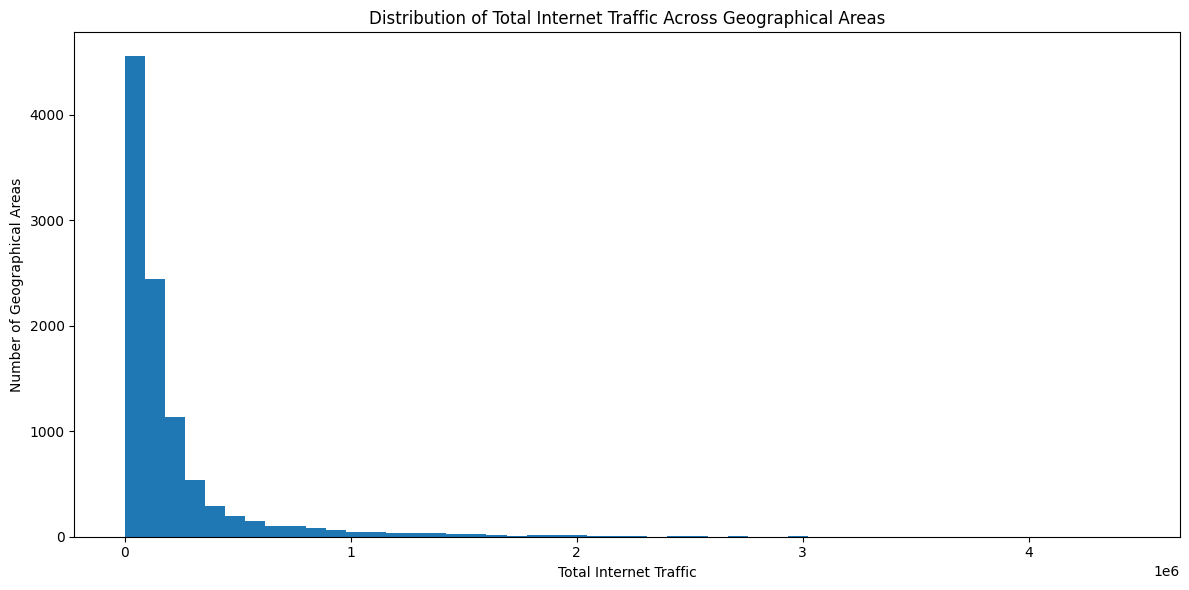

In [16]:
#Distribution figures

plt.figure(figsize=(12, 6))

plt.hist(
    area_totals["total_internet"],
    bins=50
)

plt.xlabel("Total Internet Traffic")
plt.ylabel("Number of Geographical Areas")
plt.title(
    "Distribution of Total Internet Traffic Across Geographical Areas"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURES_PATH,
        "total_internet_traffic_distribution.png"
    ),
    dpi=300
)

plt.show()

In [17]:
#Distribution statistics

print("Distribution statistics:")

display(
    area_totals["total_internet"].describe()
)

print(
    "\nSkewness:",
    area_totals["total_internet"].skew()
)

Distribution statistics:


,total_internet
count,1.000000e+04
mean,2.018401e+05
std,3.242370e+05
min,1.472790e+02
25%,4.176779e+04
50%,1.016107e+05
75%,2.072286e+05
max,4.447538e+06



Skewness: 4.2178264


In [18]:
REQUIRED_AREAS = [
    TOP_3_AREAS[0],
    TOP_3_AREAS[1],
    TOP_3_AREAS[2],
    4159,
    4556
]

print("Five required areas:")
print(REQUIRED_AREAS)

Five required areas:
[5161, 5059, 5259, 4159, 4556]


In [19]:
#First two weeks

FIRST_TWO_WEEKS = all_processed[
    (
        all_processed["datetime"]
        >= pd.Timestamp("2013-11-01")
    )
    &
    (
        all_processed["datetime"]
        <
        pd.Timestamp("2013-11-15")
    )
    &
    (
        all_processed["square_id"]
        .isin(REQUIRED_AREAS)
    )
].copy()

FIRST_TWO_WEEKS = FIRST_TWO_WEEKS.sort_values(
    ["square_id", "datetime"]
)

print(
    "Rows for five required areas:",
    len(FIRST_TWO_WEEKS)
)

display(
    FIRST_TWO_WEEKS.groupby("square_id").size()
)

Rows for five required areas: 10050


,0
square_id,
4159,2010
4556,2010
5059,2010
5161,2010
5259,2010


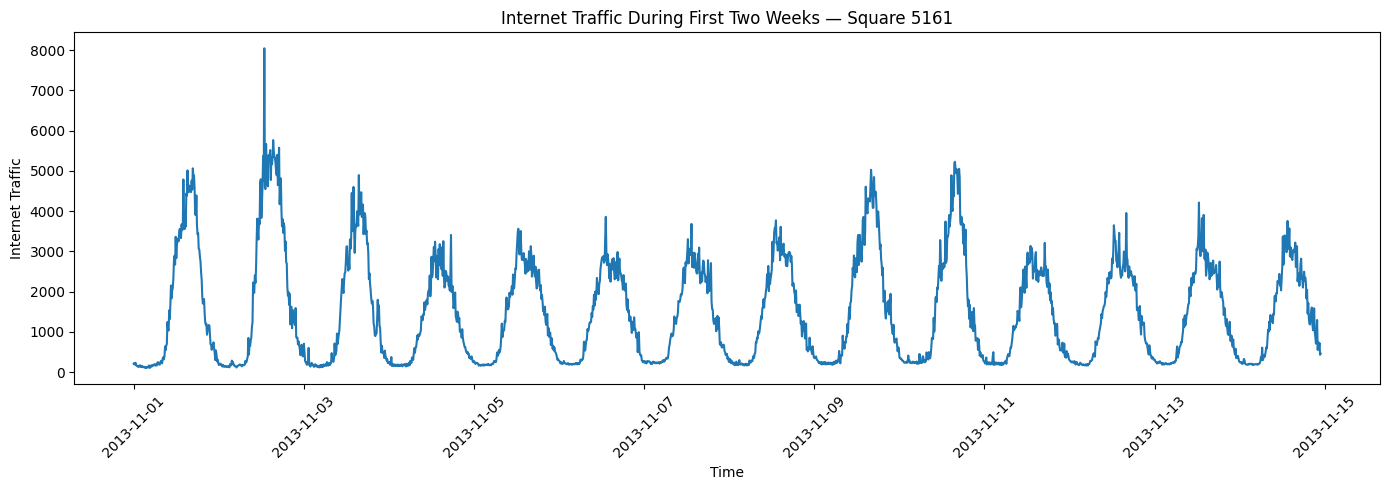

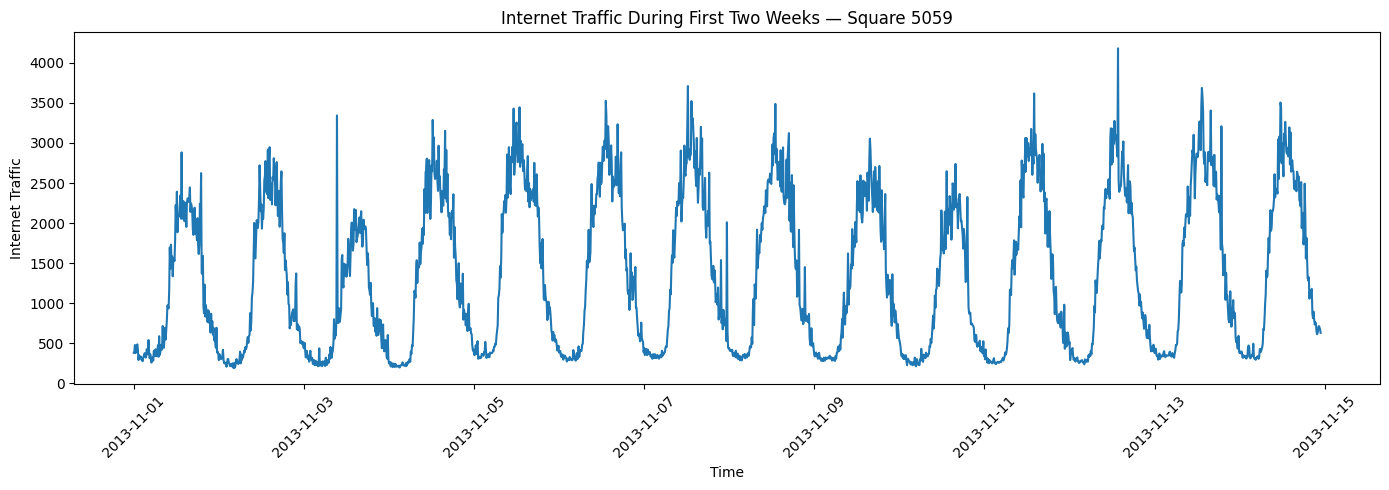

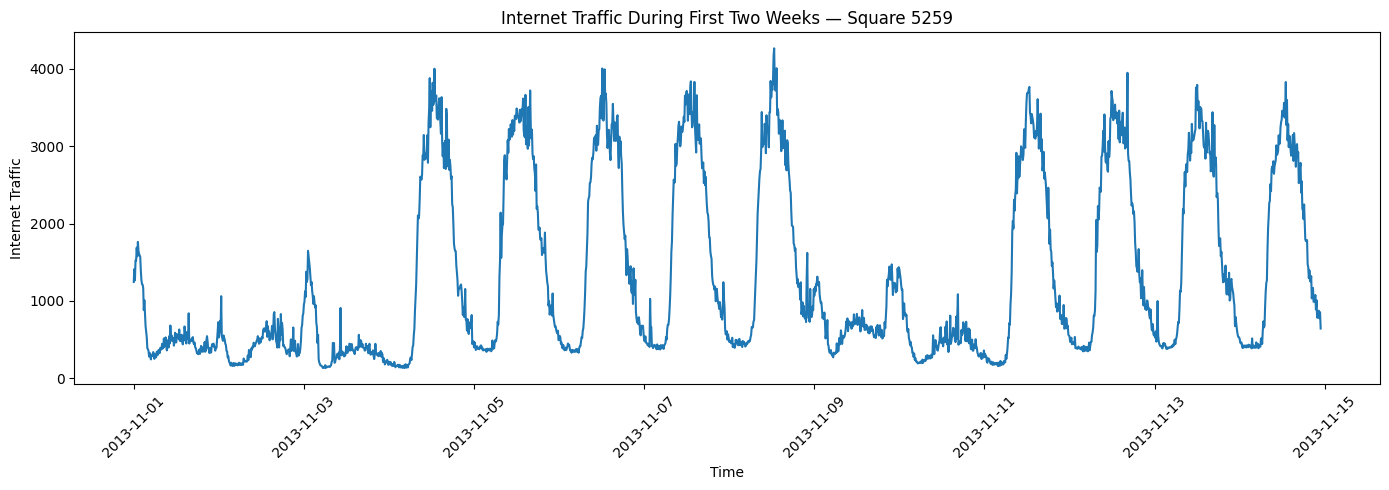

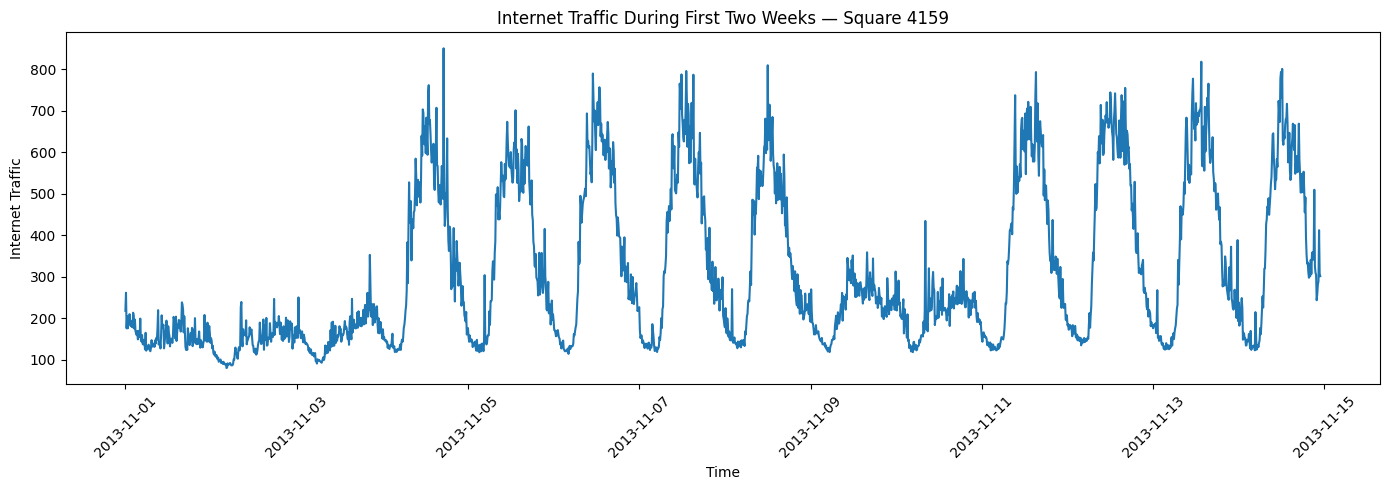

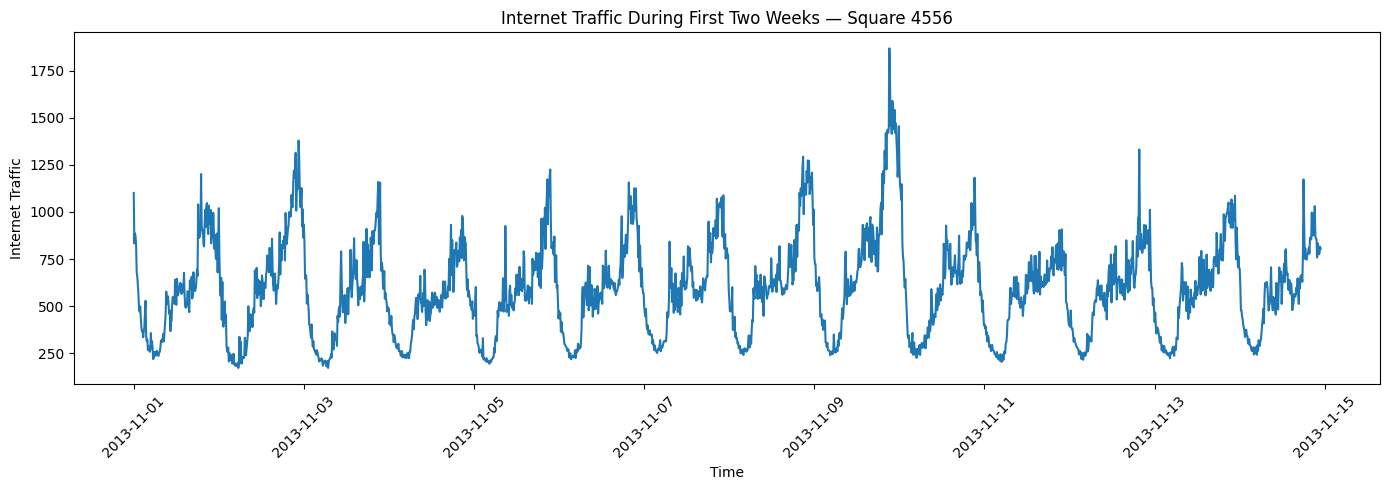

In [20]:
#Five required figures

for square_id in REQUIRED_AREAS:

    area_df = FIRST_TWO_WEEKS[
        FIRST_TWO_WEEKS["square_id"] == square_id
    ]

    plt.figure(figsize=(14, 5))

    plt.plot(
        area_df["datetime"],
        area_df["internet"]
    )

    plt.xlabel("Time")
    plt.ylabel("Internet Traffic")

    plt.title(
        f"Internet Traffic During First Two Weeks "
        f"— Square {square_id}"
    )

    plt.xticks(rotation=45)

    plt.tight_layout()

    output_path = os.path.join(
        FIGURES_PATH,
        f"square_{square_id}_first_two_weeks.png"
    )

    plt.savefig(
        output_path,
        dpi=300
    )

    plt.show()

In [21]:
#Five area comparison table

five_area_statistics = (
    FIRST_TWO_WEEKS
    .groupby("square_id")["internet"]
    .agg(
        mean="mean",
        std="std",
        minimum="min",
        maximum="max",
        median="median"
    )
    .reset_index()
)

display(five_area_statistics)

five_area_statistics.to_csv(
    os.path.join(
        RESULTS_PATH,
        "five_area_first_two_week_statistics.csv"
    ),
    index=False
)

,square_id,mean,std,minimum,maximum,median
0,4159,311.662506,189.455338,80.286430,851.051453,234.852341
1,4556,591.483459,254.988052,171.957687,1868.741943,581.717163
2,5059,1332.827759,952.947388,189.103104,4182.754883,1092.956909
3,5161,1486.916016,1313.305420,104.880028,8044.070312,1115.382568
4,5259,1294.481567,1138.219238,134.490509,4262.895020,701.708984


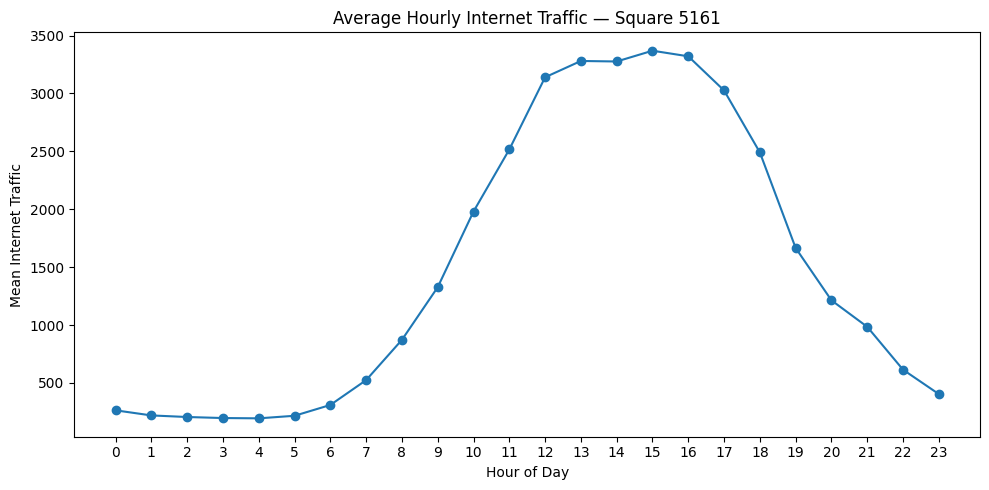

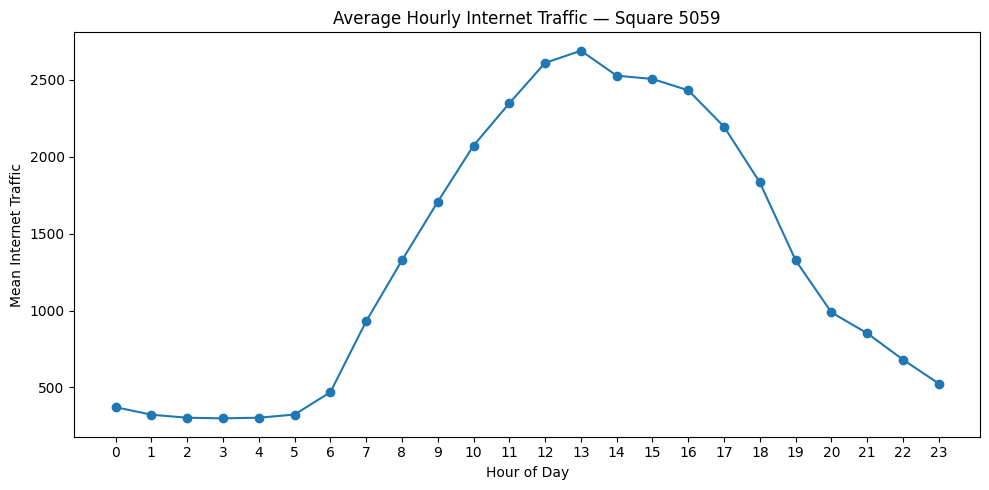

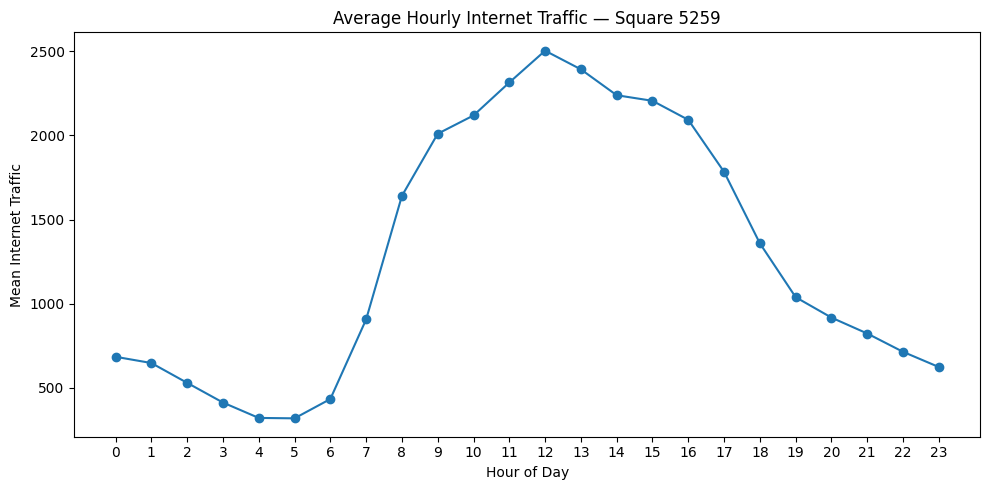

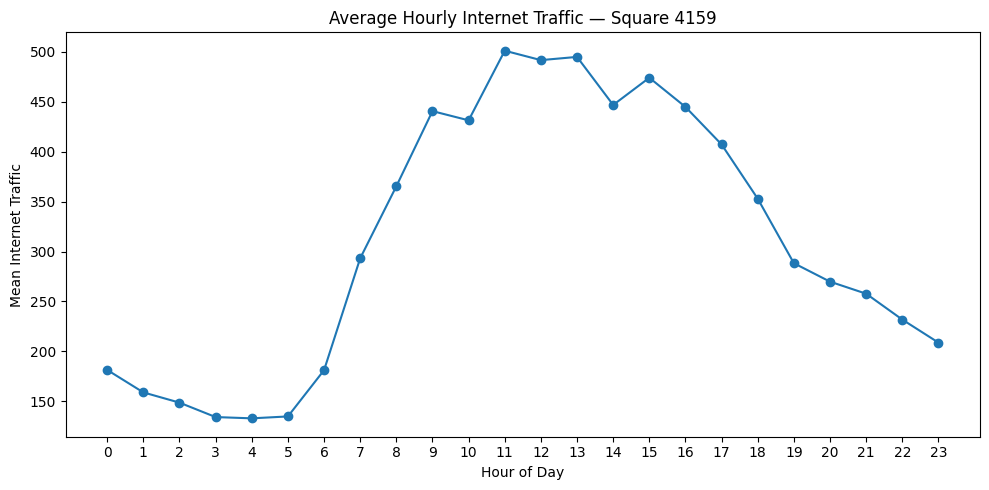

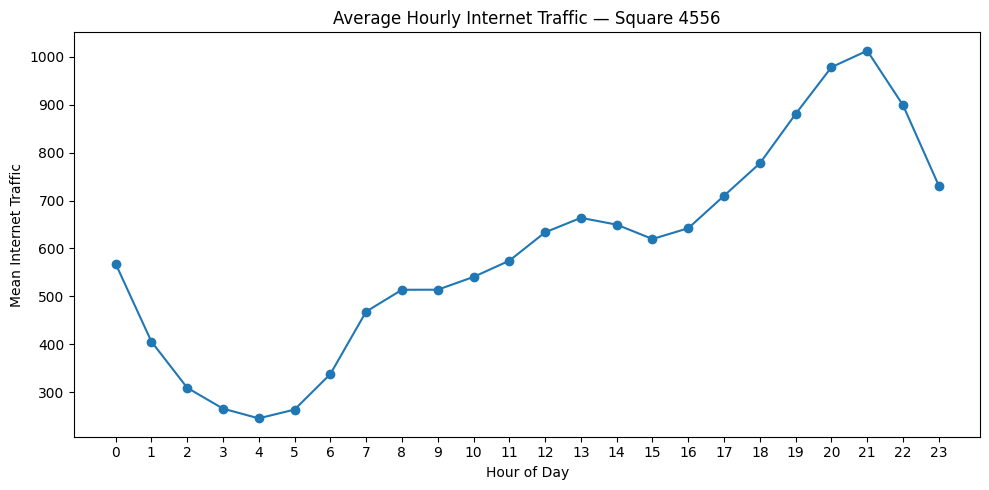

In [22]:
#Hourly profile for all five areas

hourly_profiles = (
    FIRST_TWO_WEEKS
    .assign(
        hour=FIRST_TWO_WEEKS["datetime"].dt.hour
    )
    .groupby(
        ["square_id", "hour"]
    )["internet"]
    .mean()
    .reset_index()
)

for square_id in REQUIRED_AREAS:

    area_hourly = hourly_profiles[
        hourly_profiles["square_id"] == square_id
    ]

    plt.figure(figsize=(10, 5))

    plt.plot(
        area_hourly["hour"],
        area_hourly["internet"],
        marker="o"
    )

    plt.xlabel("Hour of Day")
    plt.ylabel("Mean Internet Traffic")

    plt.title(
        f"Average Hourly Internet Traffic "
        f"— Square {square_id}"
    )

    plt.xticks(range(24))

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            FIGURES_PATH,
            f"square_{square_id}_hourly_profile.png"
        ),
        dpi=300
    )

    plt.show()

In [23]:
# Highest area - Additional analysis 1 - ACF

from statsmodels.tsa.stattools import acf

highest_area_first_two_weeks = (
    FIRST_TWO_WEEKS[
        FIRST_TWO_WEEKS["square_id"] == HIGHEST_AREA
    ]
    .sort_values("datetime")
)

highest_series = (
    highest_area_first_two_weeks["internet"]
    .dropna()
)

acf_values = acf(
    highest_series,
    nlags=72,
    fft=True
)

acf_table = pd.DataFrame({
    "lag": range(len(acf_values)),
    "autocorrelation": acf_values
})

display(
    acf_table[
        acf_table["lag"].isin(
            [1, 6, 12, 24, 36, 72]
        )
    ]
)

,lag,autocorrelation
1,1,0.975759
6,6,0.926474
12,12,0.805043
24,24,0.423367
36,36,-0.032237
72,72,-0.760487


<Figure size 1200x500 with 0 Axes>

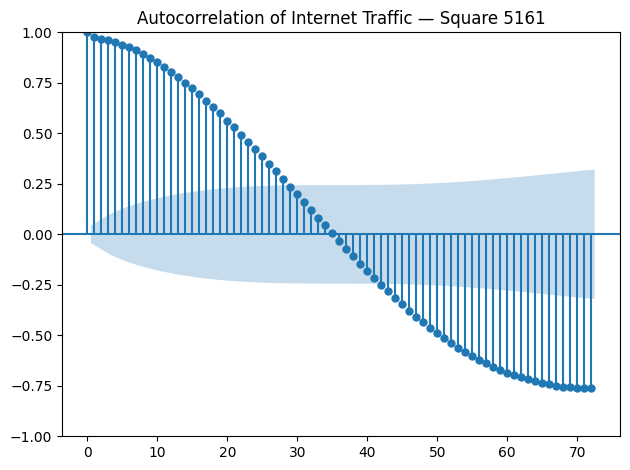

In [24]:
#ACF PLOT

from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12, 5))

plot_acf(
    highest_series,
    lags=72
)

plt.title(
    f"Autocorrelation of Internet Traffic "
    f"— Square {HIGHEST_AREA}"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURES_PATH,
        f"square_{HIGHEST_AREA}_acf.png"
    ),
    dpi=300
)

plt.show()

acf_table.to_csv(
    os.path.join(
        RESULTS_PATH,
        "highest_area_acf.csv"
    ),
    index=False
)

In [25]:
#Additional Analysis - Hourly Seasonality

highest_hourly = (
    highest_area_first_two_weeks
    .assign(
        hour=highest_area_first_two_weeks[
            "datetime"
        ].dt.hour
    )
    .groupby("hour")["internet"]
    .agg(
        mean="mean",
        std="std"
    )
    .reset_index()
)

display(highest_hourly)

,hour,mean,std
0,0,263.499084,77.751198
1,1,219.443405,60.619736
2,2,205.745605,60.030941
3,3,196.897537,36.015236
4,4,194.257278,35.794498
5,5,216.409592,48.549221
6,6,309.701263,100.005577
7,7,524.232849,235.221741
8,8,872.075806,337.001068
9,9,1326.690796,373.555023


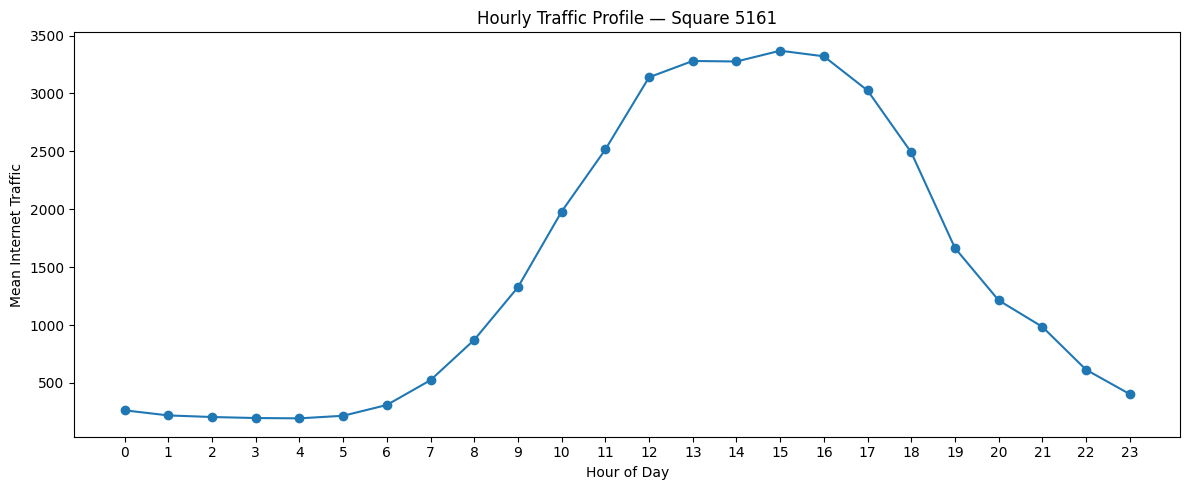

In [26]:
#PLOT

plt.figure(figsize=(12, 5))

plt.plot(
    highest_hourly["hour"],
    highest_hourly["mean"],
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Mean Internet Traffic")

plt.title(
    f"Hourly Traffic Profile "
    f"— Square {HIGHEST_AREA}"
)

plt.xticks(range(24))

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURES_PATH,
        f"square_{HIGHEST_AREA}_hourly_seasonality.png"
    ),
    dpi=300
)

plt.show()

In [27]:
#Peak and Lowest period

peak_hour = highest_hourly.loc[
    highest_hourly["mean"].idxmax()
]

lowest_hour = highest_hourly.loc[
    highest_hourly["mean"].idxmin()
]

print("Peak hour:")
display(peak_hour.to_frame().T)

print("\nLowest-traffic hour:")
display(lowest_hour.to_frame().T)

Peak hour:


,hour,mean,std
15,15.0,3368.980225,1014.958435



Lowest-traffic hour:


,hour,mean,std
4,4.0,194.257278,35.794498


In [28]:
#DECEMBER 16-22

DECEMBER_EVALUATION = all_processed[
    (
        all_processed["datetime"]
        >= pd.Timestamp("2013-12-16")
    )
    &
    (
        all_processed["datetime"]
        <
        pd.Timestamp("2013-12-23")
    )
    &
    (
        all_processed["square_id"]
        .isin(TOP_3_AREAS)
    )
].copy()

DECEMBER_EVALUATION = DECEMBER_EVALUATION.sort_values(
    ["square_id", "datetime"]
)

print(
    "December 16–22 rows:",
    len(DECEMBER_EVALUATION)
)

display(
    DECEMBER_EVALUATION.groupby(
        "square_id"
    ).size()
)

December 16–22 rows: 3006


,0
square_id,
5059,1002
5161,1002
5259,1002


In [29]:
#TRAINING DATA

TRAIN_DATA = all_processed[
    (
        all_processed["datetime"]
        >= pd.Timestamp("2013-11-01")
    )
    &
    (
        all_processed["datetime"]
        <
        pd.Timestamp("2013-11-15")
    )
    &
    (
        all_processed["square_id"]
        .isin(TOP_3_AREAS)
    )
].copy()

TRAIN_DATA = TRAIN_DATA.sort_values(
    ["square_id", "datetime"]
)

print(
    "Training rows:",
    len(TRAIN_DATA)
)

display(
    TRAIN_DATA.groupby("square_id").size()
)

Training rows: 6030


,0
square_id,
5059,2010
5161,2010
5259,2010


In [30]:
#SEQUENCE LENGTH

SEQUENCE_LENGTH = 24

print(
    "Sequence length:",
    SEQUENCE_LENGTH
)

print(
    "History represented:",
    SEQUENCE_LENGTH * 10,
    "minutes"
)

print(
    "Equivalent:",
    SEQUENCE_LENGTH * 10 / 60,
    "hours"
)

Sequence length: 24
History represented: 240 minutes
Equivalent: 4.0 hours


In [31]:
#CREATING SEQUENCES

def create_sequences(
    df,
    sequence_length=24
):

    df = (
        df
        .sort_values("datetime")
        .reset_index(drop=True)
    )

    values = df["internet"].values.astype(
        np.float32
    )

    times = pd.to_datetime(
        df["datetime"]
    ).values

    X = []
    y = []
    target_times = []

    for i in range(
        sequence_length,
        len(df)
    ):

        previous_times = pd.to_datetime(
            times[i-sequence_length:i]
        )

        current_time = pd.Timestamp(
            times[i]
        )

        expected_times = pd.date_range(
            end=current_time -
            pd.Timedelta(minutes=10),
            periods=sequence_length,
            freq="10min"
        )

        if np.array_equal(
            previous_times,
            expected_times.values
        ):

            X.append(
                values[
                    i-sequence_length:i
                ]
            )

            y.append(values[i])

            target_times.append(
                current_time
            )

    return (
        np.array(X, dtype=np.float32),
        np.array(y, dtype=np.float32),
        np.array(target_times)
    )

In [32]:
#PREPARE EACH AREA

sequence_data = {}

for square_id in TOP_3_AREAS:

    train_area = TRAIN_DATA[
        TRAIN_DATA["square_id"] == square_id
    ]

    test_area = DECEMBER_EVALUATION[
        DECEMBER_EVALUATION["square_id"] == square_id
    ]

    X_train_raw, y_train_raw, t_train = (
        create_sequences(
            train_area,
            SEQUENCE_LENGTH
        )
    )

    X_test_raw, y_test_raw, t_test = (
        create_sequences(
            test_area,
            SEQUENCE_LENGTH
        )
    )

    sequence_data[square_id] = {
        "X_train_raw": X_train_raw,
        "y_train_raw": y_train_raw,
        "t_train": t_train,
        "X_test_raw": X_test_raw,
        "y_test_raw": y_test_raw,
        "t_test": t_test
    }

    print(
        f"Square {square_id}: "
        f"{len(X_train_raw)} training sequences, "
        f"{len(X_test_raw)} test sequences"
    )

Square 5161: 1986 training sequences, 978 test sequences
Square 5059: 1986 training sequences, 978 test sequences
Square 5259: 1986 training sequences, 978 test sequences


In [33]:
#CREATE VALIDATION SPLIT

model_data = {}

for square_id in TOP_3_AREAS:

    data = sequence_data[square_id]

    n = len(data["X_train_raw"])

    split_index = int(
        n * 0.8
    )

    X_train_raw = data["X_train_raw"][
        :split_index
    ]

    y_train_raw = data["y_train_raw"][
        :split_index
    ]

    X_val_raw = data["X_train_raw"][
        split_index:
    ]

    y_val_raw = data["y_train_raw"][
        split_index:
    ]

    model_data[square_id] = {
        "X_train_raw": X_train_raw,
        "y_train_raw": y_train_raw,
        "X_val_raw": X_val_raw,
        "y_val_raw": y_val_raw,
        "X_test_raw": data["X_test_raw"],
        "y_test_raw": data["y_test_raw"],
        "test_times": data["t_test"]
    }

    print(
        square_id,
        "train:",
        len(X_train_raw),
        "validation:",
        len(X_val_raw),
        "test:",
        len(data["X_test_raw"])
    )

5161 train: 1588 validation: 398 test: 978
5059 train: 1588 validation: 398 test: 978
5259 train: 1588 validation: 398 test: 978


In [34]:
#SCALE USING DATA ONLY

for square_id in TOP_3_AREAS:

    data = model_data[square_id]

    scaler = MinMaxScaler()

    scaler.fit(
        data["X_train_raw"].reshape(-1, 1)
    )

    data["X_train"] = scaler.transform(
        data["X_train_raw"].reshape(-1, 1)
    ).reshape(
        data["X_train_raw"].shape
    )

    data["y_train"] = scaler.transform(
        data["y_train_raw"].reshape(-1, 1)
    ).reshape(-1)

    data["X_val"] = scaler.transform(
        data["X_val_raw"].reshape(-1, 1)
    ).reshape(
        data["X_val_raw"].shape
    )

    data["y_val"] = scaler.transform(
        data["y_val_raw"].reshape(-1, 1)
    ).reshape(-1)

    data["X_test"] = scaler.transform(
        data["X_test_raw"].reshape(-1, 1)
    ).reshape(
        data["X_test_raw"].shape
    )

    data["y_test"] = scaler.transform(
        data["y_test_raw"].reshape(-1, 1)
    ).reshape(-1)

    data["scaler"] = scaler

    print(
        square_id,
        "training scale:",
        scaler.data_min_[0],
        "to",
        scaler.data_max_[0]
    )

5161 training scale: 104.88003 to 8044.0703
5059 training scale: 189.1031 to 3711.1003
5259 training scale: 134.49051 to 4262.895


In [35]:
#RESHAPE OF NEURAL NETWORKS

for square_id in TOP_3_AREAS:

    data = model_data[square_id]

    data["X_train"] = data["X_train"].reshape(
        data["X_train"].shape[0],
        data["X_train"].shape[1],
        1
    )

    data["X_val"] = data["X_val"].reshape(
        data["X_val"].shape[0],
        data["X_val"].shape[1],
        1
    )

    data["X_test"] = data["X_test"].reshape(
        data["X_test"].shape[0],
        data["X_test"].shape[1],
        1
    )

print("Input shape:")
print(model_data[TOP_3_AREAS[0]]["X_train"].shape)

Input shape:
(1588, 24, 1)


In [36]:
#MODEL 1 - MLP

def build_mlp():

    model = Sequential([
        Input(
            shape=(SEQUENCE_LENGTH, 1)
        ),

        Flatten(),

        Dense(
            64,
            activation="relu"
        ),

        Dense(
            32,
            activation="relu"
        ),

        Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="mse",
        metrics=["mae"]
    )

    return model

In [37]:
#MODEL 2 - CNN

def build_cnn():

    model = Sequential([
        Input(
            shape=(SEQUENCE_LENGTH, 1)
        ),

        Conv1D(
            filters=32,
            kernel_size=3,
            activation="relu"
        ),

        MaxPooling1D(
            pool_size=2
        ),

        Flatten(),

        Dense(
            32,
            activation="relu"
        ),

        Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="mse",
        metrics=["mae"]
    )

    return model

In [38]:
#MODEL 3 - LSTM

def build_lstm():

    model = Sequential([
        Input(
            shape=(SEQUENCE_LENGTH, 1)
        ),

        LSTM(64),

        Dense(
            32,
            activation="relu"
        ),

        Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="mse",
        metrics=["mae"]
    )

    return model

In [39]:
#HYPERPARAMETER TUNING

TUNING_CONFIGS = {

    "MLP": [
        {"units": 32, "lr": 0.001},
        {"units": 64, "lr": 0.001},
        {"units": 128, "lr": 0.001},
        {"units": 64, "lr": 0.0005}
    ],

    "CNN": [
        {
            "filters": 16,
            "kernel": 3,
            "lr": 0.001
        },
        {
            "filters": 32,
            "kernel": 3,
            "lr": 0.001
        },
        {
            "filters": 64,
            "kernel": 3,
            "lr": 0.001
        },
        {
            "filters": 32,
            "kernel": 5,
            "lr": 0.001
        }
    ],

    "LSTM": [
        {"units": 32, "lr": 0.001},
        {"units": 64, "lr": 0.001},
        {"units": 128, "lr": 0.001},
        {"units": 64, "lr": 0.0005}
    ]
}

In [40]:
#TUNING BUILDERS

def build_tuned_mlp(config):

    model = Sequential([
        Input(
            shape=(SEQUENCE_LENGTH, 1)
        ),
        Flatten(),
        Dense(
            config["units"],
            activation="relu"
        ),
        Dense(
            32,
            activation="relu"
        ),
        Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=config["lr"]
        ),
        loss="mse",
        metrics=["mae"]
    )

    return model


def build_tuned_cnn(config):

    model = Sequential([
        Input(
            shape=(SEQUENCE_LENGTH, 1)
        ),
        Conv1D(
            filters=config["filters"],
            kernel_size=config["kernel"],
            activation="relu"
        ),
        MaxPooling1D(
            pool_size=2
        ),
        Flatten(),
        Dense(
            32,
            activation="relu"
        ),
        Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=config["lr"]
        ),
        loss="mse",
        metrics=["mae"]
    )

    return model


def build_tuned_lstm(config):

    model = Sequential([
        Input(
            shape=(SEQUENCE_LENGTH, 1)
        ),
        LSTM(
            config["units"]
        ),
        Dense(
            32,
            activation="relu"
        ),
        Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=config["lr"]
        ),
        loss="mse",
        metrics=["mae"]
    )

    return model


TUNED_BUILDERS = {
    "MLP": build_tuned_mlp,
    "CNN": build_tuned_cnn,
    "LSTM": build_tuned_lstm
}

In [41]:
#RUN TUNING

tuning_results = []

data = model_data[HIGHEST_AREA]

for model_name in [
    "MLP",
    "CNN",
    "LSTM"
]:

    for config_id, config in enumerate(
        TUNING_CONFIGS[model_name],
        start=1
    ):

        print(
            f"{model_name} "
            f"configuration {config_id}"
        )

        tf.keras.backend.clear_session()

        model = TUNED_BUILDERS[
            model_name
        ](config)

        start_time = time.perf_counter()

        history = model.fit(
            data["X_train"],
            data["y_train"],
            validation_data=(
                data["X_val"],
                data["y_val"]
            ),
            epochs=50,
            batch_size=32,
            callbacks=[
                EarlyStopping(
                    monitor="val_loss",
                    patience=7,
                    restore_best_weights=True
                )
            ],
            verbose=0
        )

        training_time = (
            time.perf_counter()
            - start_time
        )

        tuning_results.append({
            "model": model_name,
            "config_id": config_id,
            "configuration": str(config),
            "best_val_loss": min(
                history.history["val_loss"]
            ),
            "best_val_mae": min(
                history.history["val_mae"]
            ),
            "training_time_seconds": training_time,
            "epochs": len(
                history.history["loss"]
            )
        })

tuning_results = pd.DataFrame(
    tuning_results
)

display(tuning_results)

tuning_results.to_csv(
    os.path.join(
        RESULTS_PATH,
        "hyperparameter_tuning_results.csv"
    ),
    index=False
)

MLP configuration 1
MLP configuration 2
MLP configuration 3
MLP configuration 4
CNN configuration 1
CNN configuration 2
CNN configuration 3
CNN configuration 4
LSTM configuration 1
LSTM configuration 2
LSTM configuration 3
LSTM configuration 4


,model,config_id,configuration,best_val_loss,best_val_mae,training_time_seconds,epochs
0,MLP,1,"{'units': 32, 'lr': 0.001}",0.000880,0.019541,12.702143,47
1,MLP,2,"{'units': 64, 'lr': 0.001}",0.000826,0.018744,5.681782,23
2,MLP,3,"{'units': 128, 'lr': 0.001}",0.000828,0.018637,6.832425,20
3,MLP,4,"{'units': 64, 'lr': 0.0005}",0.000882,0.020081,5.479986,20
4,CNN,1,"{'filters': 16, 'kernel': 3, 'lr': 0.001}",0.000911,0.020113,7.041751,21
5,CNN,2,"{'filters': 32, 'kernel': 3, 'lr': 0.001}",0.000910,0.019999,6.306895,21
6,CNN,3,"{'filters': 64, 'kernel': 3, 'lr': 0.001}",0.000846,0.018951,10.640126,29
7,CNN,4,"{'filters': 32, 'kernel': 5, 'lr': 0.001}",0.000858,0.019175,14.987315,50
8,LSTM,1,"{'units': 32, 'lr': 0.001}",0.000885,0.019438,11.701364,14
9,LSTM,2,"{'units': 64, 'lr': 0.001}",0.000865,0.019001,26.946872,31


In [42]:
#SELECT BEST CONFIGURATION

best_configs = {}

for model_name in [
    "MLP",
    "CNN",
    "LSTM"
]:

    model_tuning = tuning_results[
        tuning_results["model"] == model_name
    ]

    best_row = model_tuning.loc[
        model_tuning["best_val_loss"].idxmin()
    ]

    config_id = int(
        best_row["config_id"]
    )

    best_configs[model_name] = (
        TUNING_CONFIGS[
            model_name
        ][config_id - 1]
    )

print("Selected configurations:")

for model_name, config in best_configs.items():
    print(model_name, ":", config)

Selected configurations:
MLP : {'units': 64, 'lr': 0.001}
CNN : {'filters': 64, 'kernel': 3, 'lr': 0.001}
LSTM : {'units': 64, 'lr': 0.001}


In [43]:
#FINAL TUNED MODEL

final_results = []
final_predictions = []

for square_id in TOP_3_AREAS:

    data = model_data[square_id]

    for model_name in [
        "MLP",
        "CNN",
        "LSTM"
    ]:

        print(
            f"Final {model_name} "
            f"— Square {square_id}"
        )

        tf.keras.backend.clear_session()

        model = TUNED_BUILDERS[
            model_name
        ](
            best_configs[model_name]
        )

        start_time = time.perf_counter()

        history = model.fit(
            data["X_train"],
            data["y_train"],
            validation_data=(
                data["X_val"],
                data["y_val"]
            ),
            epochs=50,
            batch_size=32,
            callbacks=[
                EarlyStopping(
                    monitor="val_loss",
                    patience=7,
                    restore_best_weights=True
                )
            ],
            verbose=0
        )

        training_time = (
            time.perf_counter()
            - start_time
        )

        prediction_start = time.perf_counter()

        pred_scaled = model.predict(
            data["X_test"],
            verbose=0
        ).reshape(-1)

        prediction_time = (
            time.perf_counter()
            - prediction_start
        )

        scaler = data["scaler"]

        y_true = scaler.inverse_transform(
            data["y_test"].reshape(-1, 1)
        ).reshape(-1)

        y_pred = scaler.inverse_transform(
            pred_scaled.reshape(-1, 1)
        ).reshape(-1)

        mae = mean_absolute_error(
            y_true,
            y_pred
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        )

        mape = (
            np.mean(
                np.abs(
                    (y_true - y_pred)
                    /
                    np.maximum(
                        np.abs(y_true),
                        1e-8
                    )
                )
            )
            * 100
        )

        final_results.append({
            "square_id": square_id,
            "model": model_name,
            "MAE": mae,
            "MAPE": mape,
            "RMSE": rmse,
            "training_time_seconds": training_time,
            "prediction_time_seconds": prediction_time,
            "epochs": len(
                history.history["loss"]
            ),
            "best_epoch": (
                np.argmin(
                    history.history["val_loss"]
                ) + 1
            )
        })

        for timestamp, actual, predicted in zip(
            data["test_times"],
            y_true,
            y_pred
        ):

            final_predictions.append({
                "square_id": square_id,
                "model": model_name,
                "datetime": timestamp,
                "actual": actual,
                "predicted": predicted
            })

final_results = pd.DataFrame(
    final_results
)

final_predictions = pd.DataFrame(
    final_predictions
)

display(final_results)

Final MLP — Square 5161
Final CNN — Square 5161
Final LSTM — Square 5161
Final MLP — Square 5059
Final CNN — Square 5059
Final LSTM — Square 5059
Final MLP — Square 5259
Final CNN — Square 5259
Final LSTM — Square 5259


,square_id,model,MAE,MAPE,RMSE,training_time_seconds,prediction_time_seconds,epochs,best_epoch
0,5161,MLP,96.115997,9.395891,144.811138,9.677566,0.207814,39,32
1,5161,CNN,112.906616,9.938557,172.567638,8.786042,0.263185,20,13
2,5161,LSTM,104.856308,9.633909,156.239862,16.691952,0.533448,17,10
3,5059,MLP,81.996063,8.426948,114.245645,8.722015,0.222726,28,21
4,5059,CNN,77.871758,8.420738,110.016347,5.872388,0.263638,17,10
5,5059,LSTM,69.581276,6.596915,100.810398,27.960010,0.503811,34,27
6,5259,MLP,69.312500,7.152539,98.932130,7.548800,0.210516,23,16
7,5259,CNN,72.321220,8.157662,100.015111,9.932393,0.367094,28,21
8,5259,LSTM,70.593208,7.772184,99.514863,40.016637,0.747889,50,48


In [44]:
#FINAL SAVED RESULTS

final_results.to_csv(
    os.path.join(
        RESULTS_PATH,
        "final_tuned_results.csv"
    ),
    index=False
)

final_predictions.to_csv(
    os.path.join(
        RESULTS_PATH,
        "final_predictions.csv"
    ),
    index=False
)

print("Final results saved.")

Final results saved.


In [45]:
#THREE PEFORMANCE TABLES

for square_id in TOP_3_AREAS:

    table = final_results[
        final_results["square_id"] == square_id
    ][
        [
            "model",
            "MAE",
            "MAPE",
            "RMSE"
        ]
    ].sort_values("MAE")

    print("=" * 60)
    print(f"SQUARE {square_id}")
    print("=" * 60)

    display(table)

    table.to_csv(
        os.path.join(
            RESULTS_PATH,
            f"performance_table_square_{square_id}.csv"
        ),
        index=False
    )

SQUARE 5161


,model,MAE,MAPE,RMSE
0,MLP,96.115997,9.395891,144.811138
2,LSTM,104.856308,9.633909,156.239862
1,CNN,112.906616,9.938557,172.567638


SQUARE 5059


,model,MAE,MAPE,RMSE
5,LSTM,69.581276,6.596915,100.810398
4,CNN,77.871758,8.420738,110.016347
3,MLP,81.996063,8.426948,114.245645


SQUARE 5259


,model,MAE,MAPE,RMSE
6,MLP,69.312500,7.152539,98.932130
8,LSTM,70.593208,7.772184,99.514863
7,CNN,72.321220,8.157662,100.015111


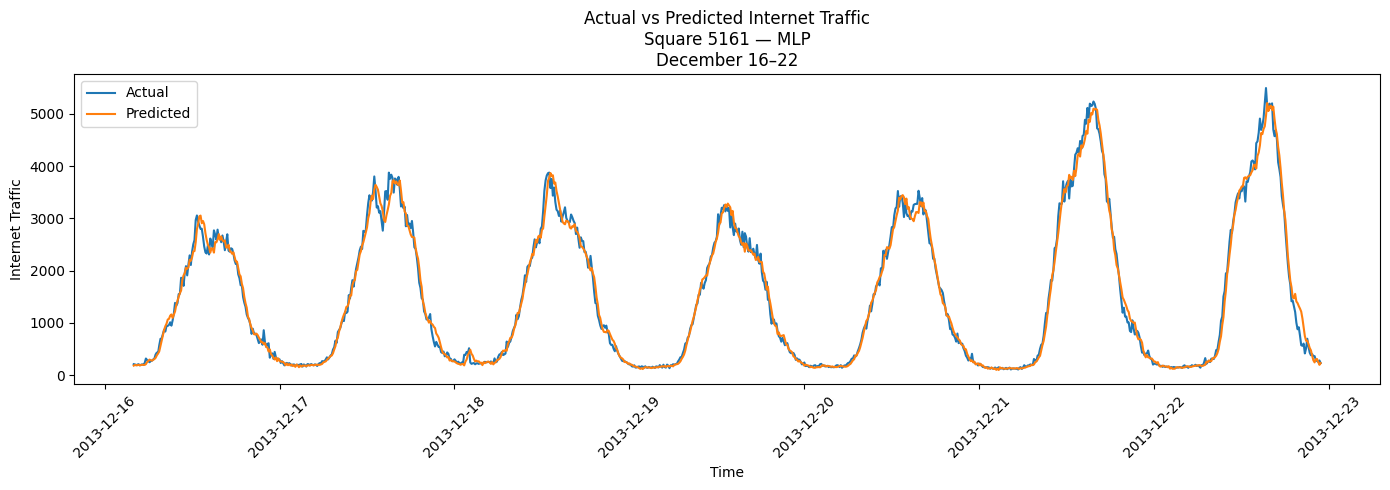

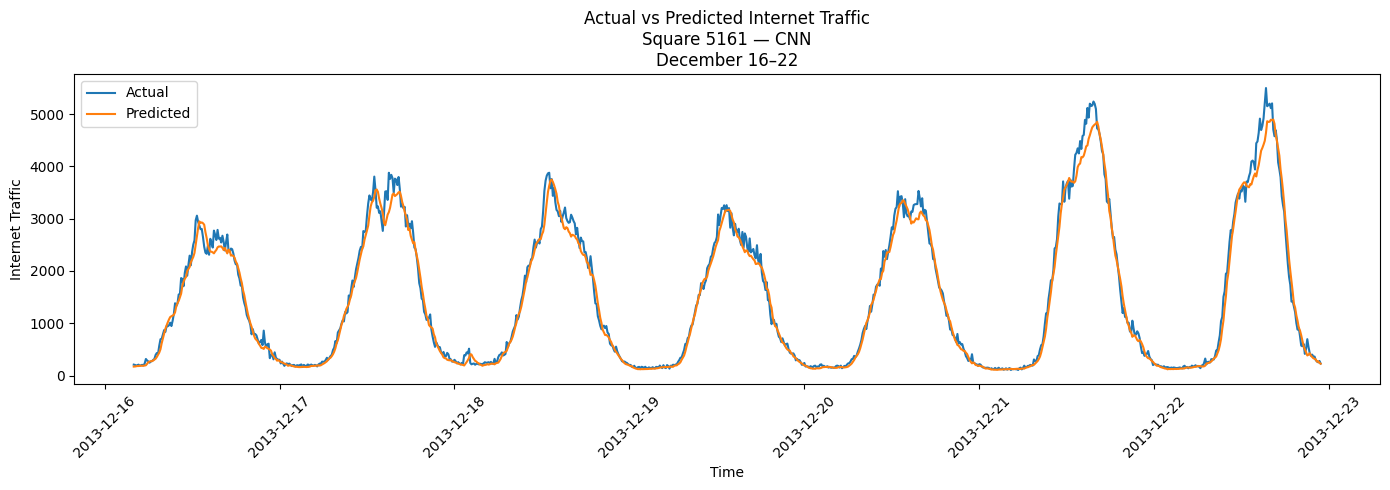

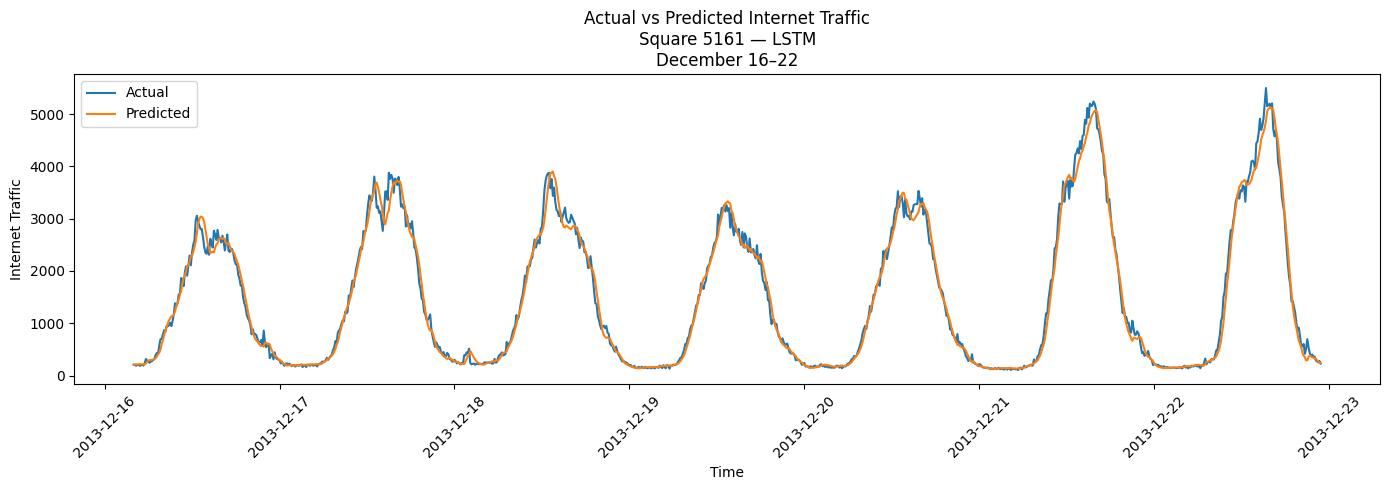

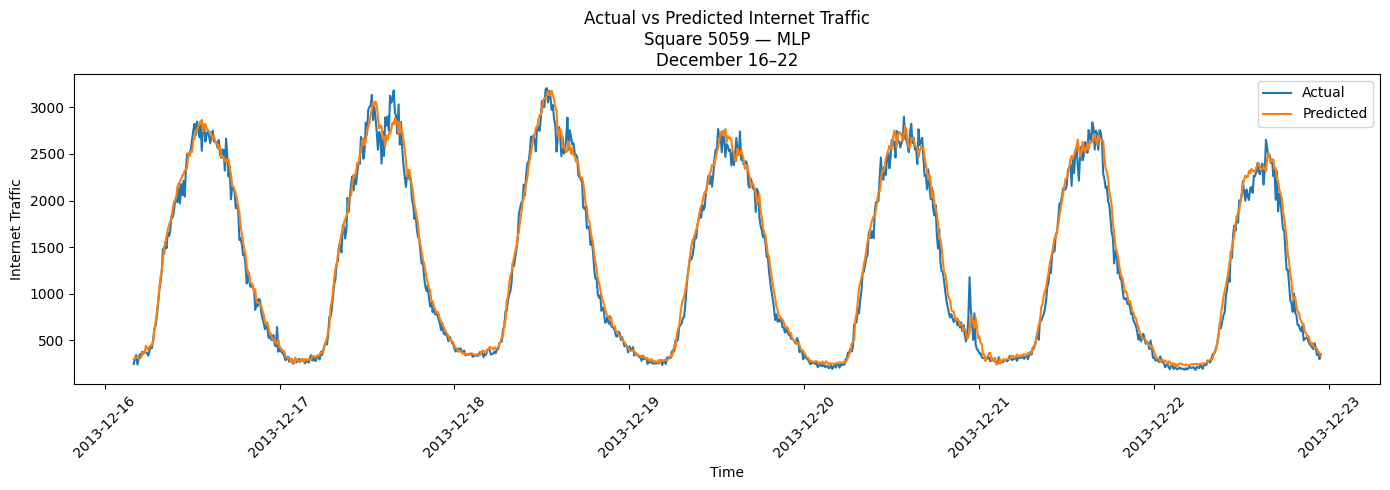

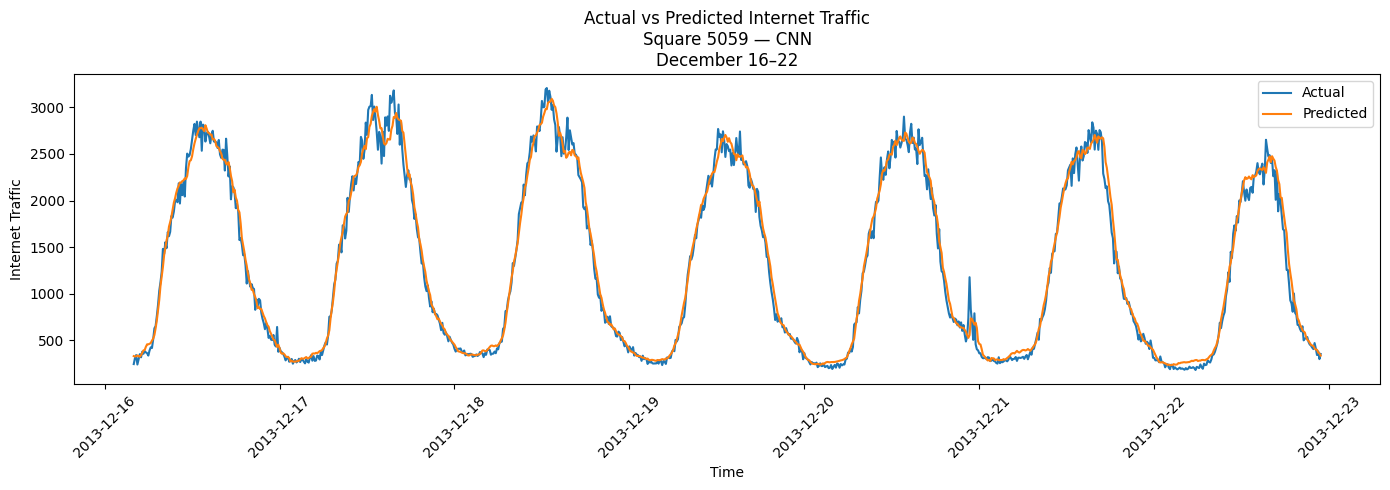

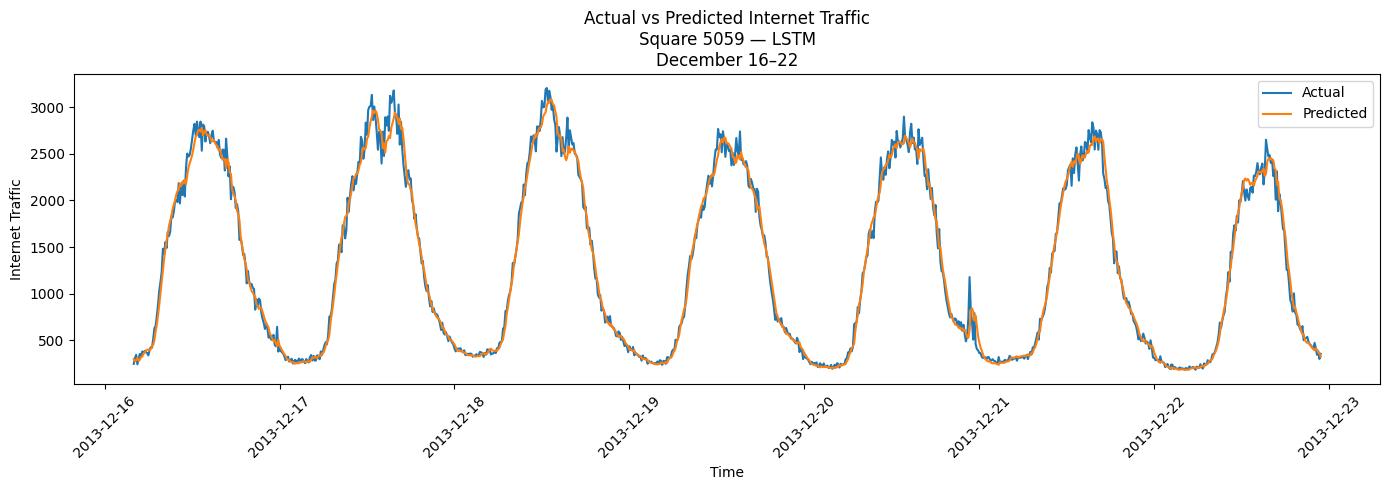

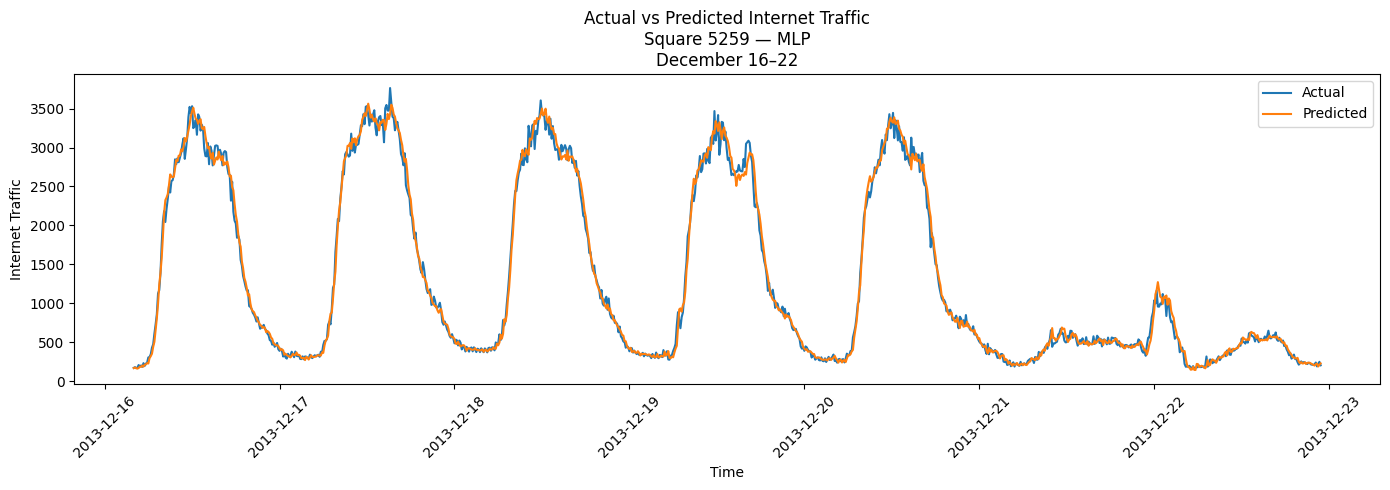

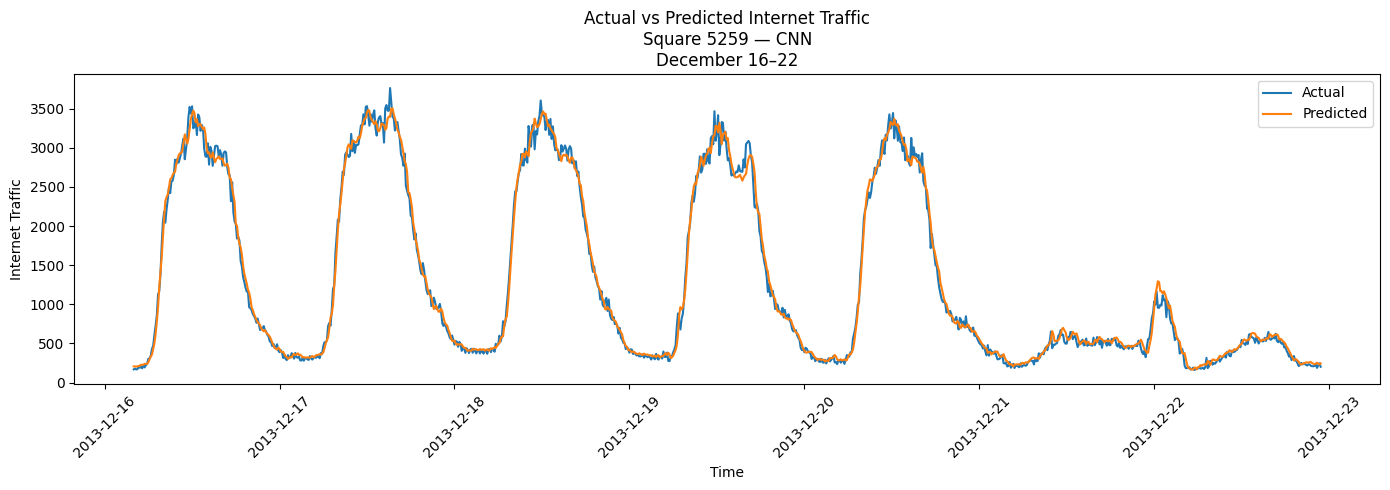

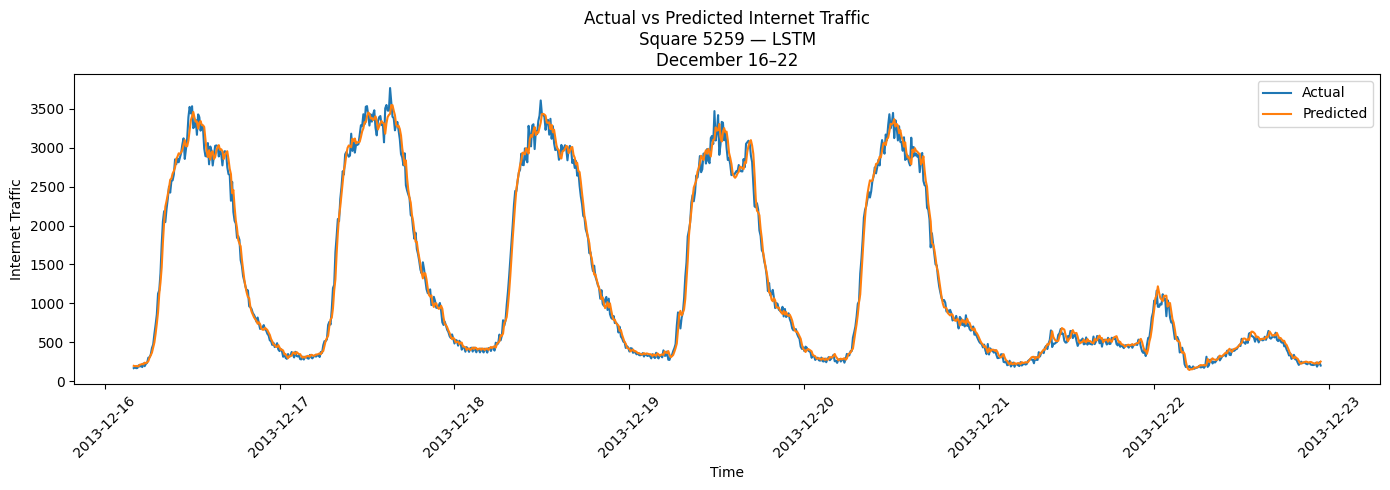

In [46]:
#NINE ACTUAL/ PREDICTED PLOTS

for square_id in TOP_3_AREAS:

    for model_name in [
        "MLP",
        "CNN",
        "LSTM"
    ]:

        plot_df = final_predictions[
            (
                final_predictions["square_id"]
                == square_id
            )
            &
            (
                final_predictions["model"]
                == model_name
            )
        ].sort_values("datetime")

        plt.figure(figsize=(14, 5))

        plt.plot(
            plot_df["datetime"],
            plot_df["actual"],
            label="Actual"
        )

        plt.plot(
            plot_df["datetime"],
            plot_df["predicted"],
            label="Predicted"
        )

        plt.xlabel("Time")
        plt.ylabel("Internet Traffic")

        plt.title(
            f"Actual vs Predicted Internet Traffic\n"
            f"Square {square_id} — {model_name}\n"
            f"December 16–22"
        )

        plt.legend()

        plt.xticks(rotation=45)

        plt.tight_layout()

        filename = (
            f"square_{square_id}_"
            f"{model_name.lower()}_"
            f"dec16_22_actual_vs_predicted.png"
        )

        plt.savefig(
            os.path.join(
                FIGURES_PATH,
                filename
            ),
            dpi=300
        )

        plt.show()

In [47]:
#OVERALL MODEL COMPARISON

overall_model_comparison = (
    final_results
    .groupby("model")
    .agg(
        mean_MAE=("MAE", "mean"),
        mean_MAPE=("MAPE", "mean"),
        mean_RMSE=("RMSE", "mean"),
        mean_training_time_seconds=(
            "training_time_seconds",
            "mean"
        ),
        mean_prediction_time_seconds=(
            "prediction_time_seconds",
            "mean"
        )
    )
    .reset_index()
)

display(overall_model_comparison)

overall_model_comparison.to_csv(
    os.path.join(
        RESULTS_PATH,
        "overall_model_comparison.csv"
    ),
    index=False
)

,model,mean_MAE,mean_MAPE,mean_RMSE,mean_training_time_seconds,mean_prediction_time_seconds
0,CNN,87.699865,8.838985,127.533032,8.196941,0.297973
1,LSTM,81.676931,8.001003,118.855041,28.222867,0.595049
2,MLP,82.474854,8.325126,119.329638,8.649460,0.213685


In [48]:
#TRAINING TIME FIGURE

overall_model_comparison = (
    final_results
    .groupby("model")
    .agg(
        mean_MAE=("MAE", "mean"),
        mean_MAPE=("MAPE", "mean"),
        mean_RMSE=("RMSE", "mean"),
        mean_training_time_seconds=(
            "training_time_seconds",
            "mean"
        ),
        mean_prediction_time_seconds=(
            "prediction_time_seconds",
            "mean"
        )
    )
    .reset_index()
)

display(overall_model_comparison)

overall_model_comparison.to_csv(
    os.path.join(
        RESULTS_PATH,
        "overall_model_comparison.csv"
    ),
    index=False
)

,model,mean_MAE,mean_MAPE,mean_RMSE,mean_training_time_seconds,mean_prediction_time_seconds
0,CNN,87.699865,8.838985,127.533032,8.196941,0.297973
1,LSTM,81.676931,8.001003,118.855041,28.222867,0.595049
2,MLP,82.474854,8.325126,119.329638,8.649460,0.213685


In [49]:
#ERROR BY AREA

area_model_comparison = (
    final_results
    .pivot(
        index="square_id",
        columns="model",
        values=[
            "MAE",
            "MAPE",
            "RMSE"
        ]
    )
)

display(area_model_comparison)

area_model_comparison.to_csv(
    os.path.join(
        RESULTS_PATH,
        "area_model_comparison.csv"
    )
)

MAE                             MAPE                      \
model             CNN        LSTM        MLP       CNN      LSTM       MLP   
square_id                                                                    
5059        77.871758   69.581276  81.996063  8.420738  6.596915  8.426948   
5161       112.906616  104.856308  96.115997  9.938557  9.633909  9.395891   
5259        72.321220   70.593208  69.312500  8.157662  7.772184  7.152539   

                 RMSE                          
model             CNN        LSTM         MLP  
square_id                                      
5059       110.016347  100.810398  114.245645  
5161       172.567638  156.239862  144.811138  
5259       100.015111   99.514863   98.932130

In [50]:
#FAILURE ANALYSIS

failure_analysis = final_predictions.copy()

failure_analysis["absolute_error"] = (
    np.abs(
        failure_analysis["actual"]
        -
        failure_analysis["predicted"]
    )
)

failure_analysis["percentage_error"] = (
    failure_analysis["absolute_error"]
    /
    np.maximum(
        np.abs(
            failure_analysis["actual"]
        ),
        1e-8
    )
) * 100

worst_predictions = (
    failure_analysis
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .groupby(
        ["square_id", "model"]
    )
    .head(10)
)

display(worst_predictions)

worst_predictions.to_csv(
    os.path.join(
        RESULTS_PATH,
        "failure_analysis.csv"
    ),
    index=False
)

,square_id,model,datetime,actual,predicted,absolute_error,percentage_error
1910,5161,CNN,2013-12-22 15:20:00,5496.440430,4641.441895,854.998535,15.555495
1905,5161,CNN,2013-12-22 14:30:00,4911.653809,4158.743652,752.910156,15.329056
1188,5161,CNN,2013-12-17 15:00:00,3876.959717,3125.014404,751.945312,19.395233
2166,5161,LSTM,2013-12-17 15:00:00,3876.959717,3154.744141,722.215576,18.628401
1763,5161,CNN,2013-12-21 14:50:00,5115.530273,4397.391602,718.138672,14.038402
...,...,...,...,...,...,...,...
5091,5059,LSTM,2013-12-17 13:30:00,2544.754150,2870.839844,326.085693,12.814034
5094,5059,LSTM,2013-12-17 14:00:00,2396.327881,2719.319336,322.991455,13.478600
7502,5259,CNN,2013-12-20 17:20:00,1719.537842,2040.342773,320.804932,18.656462
5948,5259,MLP,2013-12-16 17:20:00,2317.724854,2638.231201,320.506348,13.828489


In [51]:
#PEAK UNDERPREDICTION

failure_analysis["underprediction"] = (
    failure_analysis["actual"]
    -
    failure_analysis["predicted"]
)

peak_underprediction = (
    failure_analysis[
        failure_analysis["underprediction"] > 0
    ]
    .sort_values(
        "underprediction",
        ascending=False
    )
    .groupby(
        ["square_id", "model"]
    )
    .head(5)
)

display(peak_underprediction)

peak_underprediction.to_csv(
    os.path.join(
        RESULTS_PATH,
        "peak_underprediction_analysis.csv"
    ),
    index=False
)

,square_id,model,datetime,actual,predicted,absolute_error,percentage_error,underprediction
1910,5161,CNN,2013-12-22 15:20:00,5496.440430,4641.441895,854.998535,15.555495,854.998535
1905,5161,CNN,2013-12-22 14:30:00,4911.653809,4158.743652,752.910156,15.329056,752.910156
1188,5161,CNN,2013-12-17 15:00:00,3876.959717,3125.014404,751.945312,19.395233,751.945312
2166,5161,LSTM,2013-12-17 15:00:00,3876.959717,3154.744141,722.215576,18.628401,722.215576
1763,5161,CNN,2013-12-21 14:50:00,5115.530273,4397.391602,718.138672,14.038402,718.138672
1909,5161,CNN,2013-12-22 15:10:00,5202.037109,4487.592773,714.444336,13.733933,714.444336
2163,5161,LSTM,2013-12-17 14:30:00,3517.677979,2891.532715,626.145264,17.799959,626.145264
2888,5161,LSTM,2013-12-22 15:20:00,5496.440430,4874.260742,622.179688,11.319684,622.179688
4600,5059,CNN,2013-12-20 22:40:00,1177.438354,556.402344,621.036011,52.744675,621.036011
210,5161,MLP,2013-12-17 15:00:00,3876.959717,3267.103760,609.855957,15.730264,609.855957


In [52]:
#SYSTEMATIC BIAS

bias_summary = (
    failure_analysis
    .assign(
        error=lambda x:
        x["predicted"] - x["actual"]
    )
    .groupby(
        ["square_id", "model"]
    )
    .agg(
        mean_error=("error", "mean"),
        mean_absolute_error=(
            "absolute_error",
            "mean"
        )
    )
    .reset_index()
)

display(bias_summary)

bias_summary.to_csv(
    os.path.join(
        RESULTS_PATH,
        "systematic_bias_analysis.csv"
    ),
    index=False
)

,square_id,model,mean_error,mean_absolute_error
0,5059,CNN,23.997602,77.871758
1,5059,LSTM,-6.388272,69.581284
2,5059,MLP,41.597340,81.996063
3,5161,CNN,-52.623249,112.906609
4,5161,LSTM,-15.768807,104.856300
5,5161,MLP,-3.587303,96.115997
6,5259,CNN,14.602276,72.321220
7,5259,LSTM,11.360430,70.593208
8,5259,MLP,9.248286,69.312500


In [53]:
#AREA CHARACTRISTICS

area_characteristics = (
    FIRST_TWO_WEEKS
    .groupby("square_id")["internet"]
    .agg(
        mean="mean",
        std="std",
        minimum="min",
        maximum="max",
        median="median"
    )
    .reset_index()
)

area_characteristics["coefficient_of_variation"] = (
    area_characteristics["std"]
    /
    area_characteristics["mean"]
)

display(area_characteristics)

area_characteristics.to_csv(
    os.path.join(
        RESULTS_PATH,
        "area_traffic_characteristics.csv"
    ),
    index=False
)

,square_id,mean,std,minimum,maximum,median,coefficient_of_variation
0,4159,311.662506,189.455338,80.286430,851.051453,234.852341,0.607886
1,4556,591.483459,254.988052,171.957687,1868.741943,581.717163,0.431099
2,5059,1332.827759,952.947388,189.103104,4182.754883,1092.956909,0.714982
3,5161,1486.916016,1313.305420,104.880028,8044.070312,1115.382568,0.883241
4,5259,1294.481567,1138.219238,134.490509,4262.895020,701.708984,0.879286


In [54]:
#LINKING AREA CHARACTERISTICS TO PERFORMANCE

performance_characteristics = final_results.merge(
    area_characteristics,
    on="square_id",
    how="left"
)

display(performance_characteristics)

performance_characteristics.to_csv(
    os.path.join(
        RESULTS_PATH,
        "performance_vs_area_characteristics.csv"
    ),
    index=False
)

,square_id,model,MAE,MAPE,RMSE,training_time_seconds,prediction_time_seconds,epochs,best_epoch,mean,std,minimum,maximum,median,coefficient_of_variation
0,5161,MLP,96.115997,9.395891,144.811138,9.677566,0.207814,39,32,1486.916016,1313.305420,104.880028,8044.070312,1115.382568,0.883241
1,5161,CNN,112.906616,9.938557,172.567638,8.786042,0.263185,20,13,1486.916016,1313.305420,104.880028,8044.070312,1115.382568,0.883241
2,5161,LSTM,104.856308,9.633909,156.239862,16.691952,0.533448,17,10,1486.916016,1313.305420,104.880028,8044.070312,1115.382568,0.883241
3,5059,MLP,81.996063,8.426948,114.245645,8.722015,0.222726,28,21,1332.827759,952.947388,189.103104,4182.754883,1092.956909,0.714982
4,5059,CNN,77.871758,8.420738,110.016347,5.872388,0.263638,17,10,1332.827759,952.947388,189.103104,4182.754883,1092.956909,0.714982
5,5059,LSTM,69.581276,6.596915,100.810398,27.960010,0.503811,34,27,1332.827759,952.947388,189.103104,4182.754883,1092.956909,0.714982
6,5259,MLP,69.312500,7.152539,98.932130,7.548800,0.210516,23,16,1294.481567,1138.219238,134.490509,4262.895020,701.708984,0.879286
7,5259,CNN,72.321220,8.157662,100.015111,9.932393,0.367094,28,21,1294.481567,1138.219238,134.490509,4262.895020,701.708984,0.879286
8,5259,LSTM,70.593208,7.772184,99.514863,40.016637,0.747889,50,48,1294.481567,1138.219238,134.490509,4262.895020,701.708984,0.879286


In [55]:
#EXECUTION INFORMATION

import platform

hardware_info = {
    "platform": platform.platform(),
    "processor": platform.processor(),
    "python_version": platform.python_version(),
    "tensorflow_version": tf.__version__,
    "gpu_devices": [
        device.name
        for device in tf.config.list_physical_devices(
            "GPU"
        )
    ]
}

print(
    json.dumps(
        hardware_info,
        indent=4
    )
)

with open(
    os.path.join(
        RESULTS_PATH,
        "hardware_information.json"
    ),
    "w"
) as f:

    json.dump(
        hardware_info,
        f,
        indent=4
    )

{
    "platform": "Linux-6.6.122+-x86_64-with-glibc2.39",
    "processor": "x86_64",
    "python_version": "3.13.15",
    "tensorflow_version": "2.20.0",
    "gpu_devices": []
}


In [56]:
#FINAL RESULT MASTER TABLE

master_final_results = final_results.merge(
    area_characteristics,
    on="square_id",
    how="left"
)

display(master_final_results)

master_final_results.to_csv(
    os.path.join(
        RESULTS_PATH,
        "master_final_results.csv"
    ),
    index=False
)

,square_id,model,MAE,MAPE,RMSE,training_time_seconds,prediction_time_seconds,epochs,best_epoch,mean,std,minimum,maximum,median,coefficient_of_variation
0,5161,MLP,96.115997,9.395891,144.811138,9.677566,0.207814,39,32,1486.916016,1313.305420,104.880028,8044.070312,1115.382568,0.883241
1,5161,CNN,112.906616,9.938557,172.567638,8.786042,0.263185,20,13,1486.916016,1313.305420,104.880028,8044.070312,1115.382568,0.883241
2,5161,LSTM,104.856308,9.633909,156.239862,16.691952,0.533448,17,10,1486.916016,1313.305420,104.880028,8044.070312,1115.382568,0.883241
3,5059,MLP,81.996063,8.426948,114.245645,8.722015,0.222726,28,21,1332.827759,952.947388,189.103104,4182.754883,1092.956909,0.714982
4,5059,CNN,77.871758,8.420738,110.016347,5.872388,0.263638,17,10,1332.827759,952.947388,189.103104,4182.754883,1092.956909,0.714982
5,5059,LSTM,69.581276,6.596915,100.810398,27.960010,0.503811,34,27,1332.827759,952.947388,189.103104,4182.754883,1092.956909,0.714982
6,5259,MLP,69.312500,7.152539,98.932130,7.548800,0.210516,23,16,1294.481567,1138.219238,134.490509,4262.895020,701.708984,0.879286
7,5259,CNN,72.321220,8.157662,100.015111,9.932393,0.367094,28,21,1294.481567,1138.219238,134.490509,4262.895020,701.708984,0.879286
8,5259,LSTM,70.593208,7.772184,99.514863,40.016637,0.747889,50,48,1294.481567,1138.219238,134.490509,4262.895020,701.708984,0.879286


In [57]:
#FINAL FILE CHECK

required_result_files = [

    "area_total_internet_traffic.csv",

    "five_area_first_two_week_statistics.csv",

    "highest_area_acf.csv",

    "baseline_results.csv",

    "hyperparameter_tuning_results.csv",

    "final_tuned_results.csv",

    "final_predictions.csv",

    "overall_model_comparison.csv",

    "area_model_comparison.csv",

    "failure_analysis.csv",

    "peak_underprediction_analysis.csv",

    "systematic_bias_analysis.csv",

    "area_traffic_characteristics.csv",

    "performance_vs_area_characteristics.csv",

    "hardware_information.json",

    "master_final_results.csv"
]

print("=" * 70)
print("RESULT FILE AUDIT")
print("=" * 70)

for filename in required_result_files:

    path = os.path.join(
        RESULTS_PATH,
        filename
    )

    status = "✓" if os.path.exists(path) else "✗"

    print(status, filename)

RESULT FILE AUDIT
✓ area_total_internet_traffic.csv
✓ five_area_first_two_week_statistics.csv
✓ highest_area_acf.csv
✗ baseline_results.csv
✓ hyperparameter_tuning_results.csv
✓ final_tuned_results.csv
✓ final_predictions.csv
✓ overall_model_comparison.csv
✓ area_model_comparison.csv
✓ failure_analysis.csv
✓ peak_underprediction_analysis.csv
✓ systematic_bias_analysis.csv
✓ area_traffic_characteristics.csv
✓ performance_vs_area_characteristics.csv
✓ hardware_information.json
✓ master_final_results.csv


In [58]:
#FINAL FIGURE CHECK

figure_files = sorted(
    glob.glob(
        os.path.join(
            FIGURES_PATH,
            "*"
        )
    )
)

print("=" * 70)
print("FIGURE AUDIT")
print("=" * 70)

print(
    "Number of figure files:",
    len(figure_files)
)

for f in figure_files:
    print(
        "✓",
        os.path.basename(f)
    )

FIGURE AUDIT
Number of figure files: 22
✓ square_4159_first_two_weeks.png
✓ square_4159_hourly_profile.png
✓ square_4556_first_two_weeks.png
✓ square_4556_hourly_profile.png
✓ square_5059_cnn_dec16_22_actual_vs_predicted.png
✓ square_5059_first_two_weeks.png
✓ square_5059_hourly_profile.png
✓ square_5059_lstm_dec16_22_actual_vs_predicted.png
✓ square_5059_mlp_dec16_22_actual_vs_predicted.png
✓ square_5161_acf.png
✓ square_5161_cnn_dec16_22_actual_vs_predicted.png
✓ square_5161_first_two_weeks.png
✓ square_5161_hourly_profile.png
✓ square_5161_hourly_seasonality.png
✓ square_5161_lstm_dec16_22_actual_vs_predicted.png
✓ square_5161_mlp_dec16_22_actual_vs_predicted.png
✓ square_5259_cnn_dec16_22_actual_vs_predicted.png
✓ square_5259_first_two_weeks.png
✓ square_5259_hourly_profile.png
✓ square_5259_lstm_dec16_22_actual_vs_predicted.png
✓ square_5259_mlp_dec16_22_actual_vs_predicted.png
✓ total_internet_traffic_distribution.png


In [59]:
#FIND ALL RESULTS FILE

import glob
import os

result_files = sorted(
    glob.glob(
        os.path.join(
            RESULTS_PATH,
            "*"
        )
    )
)

print("=" * 70)
print("RESULTS AUDIT")
print("=" * 70)

print(
    "Number of result files:",
    len(result_files)
)

for f in result_files:
    print("✓", os.path.basename(f))

RESULTS AUDIT
Number of result files: 19
✓ area_model_comparison.csv
✓ area_total_internet_traffic.csv
✓ area_traffic_characteristics.csv
✓ failure_analysis.csv
✓ final_predictions.csv
✓ final_tuned_results.csv
✓ five_area_first_two_week_statistics.csv
✓ hardware_information.json
✓ highest_area_acf.csv
✓ hyperparameter_tuning_results.csv
✓ master_final_results.csv
✓ overall_model_comparison.csv
✓ peak_underprediction_analysis.csv
✓ performance_table_square_5059.csv
✓ performance_table_square_5161.csv
✓ performance_table_square_5259.csv
✓ performance_vs_area_characteristics.csv
✓ selected_area_statistics.csv
✓ systematic_bias_analysis.csv


In [60]:
#INSPECT RESULTS FOLDER

print("=" * 70)
print("RESULT FILE DETAILS")
print("=" * 70)

for f in result_files:
    print(
        os.path.basename(f),
        "|",
        round(os.path.getsize(f) / 1024, 2),
        "KB"
    )

RESULT FILE DETAILS
area_model_comparison.csv | 0.59 KB
area_total_internet_traffic.csv | 142.34 KB
area_traffic_characteristics.csv | 0.37 KB
failure_analysis.csv | 6.06 KB
final_predictions.csv | 418.49 KB
final_tuned_results.csv | 0.95 KB
five_area_first_two_week_statistics.csv | 0.3 KB
hardware_information.json | 0.17 KB
highest_area_acf.csv | 1.62 KB
hyperparameter_tuning_results.csv | 1.31 KB
master_final_results.csv | 1.51 KB
overall_model_comparison.csv | 0.34 KB
peak_underprediction_analysis.csv | 3.5 KB
performance_table_square_5059.csv | 0.17 KB
performance_table_square_5161.csv | 0.17 KB
performance_table_square_5259.csv | 0.16 KB
performance_vs_area_characteristics.csv | 1.51 KB
selected_area_statistics.csv | 0.34 KB
systematic_bias_analysis.csv | 0.29 KB


In [61]:
#CHECK MODEL PREDICTION FILE

prediction_files = sorted(
    glob.glob(
        os.path.join(
            RESULTS_PATH,
            "*pred*"
        )
    )
)

print("=" * 70)
print("PREDICTION FILES")
print("=" * 70)

for f in prediction_files:
    print("✓", os.path.basename(f))

PREDICTION FILES
✓ final_predictions.csv
✓ peak_underprediction_analysis.csv


In [62]:
#CHECKING FOR METRICS

metric_files = sorted(
    glob.glob(
        os.path.join(
            RESULTS_PATH,
            "*metric*"
        )
    )
)

print("=" * 70)
print("METRIC FILES")
print("=" * 70)

for f in metric_files:
    print("✓", os.path.basename(f))

METRIC FILES


In [64]:
# BASELINE EXPERIMENTS


baseline_results = []

BASELINE_MODELS = {
    "MLP": build_mlp,
    "CNN": build_cnn,
    "LSTM": build_lstm
}

print("=" * 70)
print("BASELINE EXPERIMENTS")
print("=" * 70)

# Baseline experiments are conducted on the highest-traffic area
# using the same chronological training/validation split.

data = model_data[HIGHEST_AREA]

for model_name, builder in BASELINE_MODELS.items():

    print(f"\nRunning baseline {model_name}...")

    tf.keras.backend.clear_session()

    model = builder()

    start_time = time.perf_counter()

    history = model.fit(
        data["X_train"],
        data["y_train"],
        validation_data=(
            data["X_val"],
            data["y_val"]
        ),
        epochs=50,
        batch_size=32,
        callbacks=[
            EarlyStopping(
                monitor="val_loss",
                patience=7,
                restore_best_weights=True
            )
        ],
        verbose=0
    )

    training_time = (
        time.perf_counter()
        - start_time
    )

    prediction_start = time.perf_counter()

    pred_scaled = model.predict(
        data["X_test"],
        verbose=0
    ).reshape(-1)

    prediction_time = (
        time.perf_counter()
        - prediction_start
    )

    scaler = data["scaler"]

    y_true = scaler.inverse_transform(
        data["y_test"].reshape(-1, 1)
    ).reshape(-1)

    y_pred = scaler.inverse_transform(
        pred_scaled.reshape(-1, 1)
    ).reshape(-1)

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    # MAPE calculated only where actual traffic is non-zero
    nonzero_mask = np.abs(y_true) > 1e-8

    if nonzero_mask.sum() > 0:
        mape = (
            np.mean(
                np.abs(
                    (
                        y_true[nonzero_mask]
                        -
                        y_pred[nonzero_mask]
                    )
                    /
                    np.abs(y_true[nonzero_mask])
                )
            )
            * 100
        )
    else:
        mape = np.nan

    baseline_results.append({
        "square_id": HIGHEST_AREA,
        "model": model_name,
        "MAE": mae,
        "MAPE": mape,
        "RMSE": rmse,
        "training_time_seconds": training_time,
        "prediction_time_seconds": prediction_time,
        "epochs": len(history.history["loss"]),
        "best_epoch": (
            np.argmin(
                history.history["val_loss"]
            ) + 1
        )
    })

    print(
        f"{model_name}: "
        f"MAE={mae:.4f}, "
        f"MAPE={mape:.2f}%, "
        f"RMSE={rmse:.4f}, "
        f"Training={training_time:.2f}s"
    )

baseline_results = pd.DataFrame(
    baseline_results
)

display(baseline_results)

BASELINE EXPERIMENTS

Running baseline MLP...
MLP: MAE=114.2532, MAPE=14.06%, RMSE=163.7241, Training=8.60s

Running baseline CNN...
CNN: MAE=108.8009, MAPE=11.88%, RMSE=161.4520, Training=12.68s

Running baseline LSTM...
LSTM: MAE=100.8048, MAPE=10.28%, RMSE=148.4488, Training=22.82s


,square_id,model,MAE,MAPE,RMSE,training_time_seconds,prediction_time_seconds,epochs,best_epoch
0,5161,MLP,114.253181,14.060633,163.724133,8.600041,0.206552,17,10
1,5161,CNN,108.800934,11.881621,161.452035,12.683481,0.227109,29,22
2,5161,LSTM,100.804825,10.280226,148.448848,22.817129,0.683635,26,19


In [65]:
#Save baseline results

baseline_results_path = os.path.join(
    RESULTS_PATH,
    "baseline_results.csv"
)

baseline_results.to_csv(
    baseline_results_path,
    index=False
)

print(
    "Baseline results saved to:",
    baseline_results_path
)

Baseline results saved to: /content/drive/MyDrive/mobile_traffic_forecasting/results/baseline_results.csv


In [66]:
# FINAL METRICS WITH ZERO-ACTUAL MAPE HANDLING


corrected_final_results = []

for square_id in TOP_3_AREAS:

    for model_name in ["MLP", "CNN", "LSTM"]:

        subset = final_predictions[
            (
                final_predictions["square_id"]
                == square_id
            )
            &
            (
                final_predictions["model"]
                == model_name
            )
        ].sort_values("datetime")

        y_true = subset["actual"].to_numpy()
        y_pred = subset["predicted"].to_numpy()

        mae = mean_absolute_error(
            y_true,
            y_pred
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        )

        nonzero_mask = np.abs(y_true) > 1e-8

        if nonzero_mask.sum() > 0:

            mape = (
                np.mean(
                    np.abs(
                        (
                            y_true[nonzero_mask]
                            -
                            y_pred[nonzero_mask]
                        )
                        /
                        np.abs(
                            y_true[nonzero_mask]
                        )
                    )
                )
                * 100
            )

        else:
            mape = np.nan

        original_row = final_results[
            (
                final_results["square_id"]
                == square_id
            )
            &
            (
                final_results["model"]
                == model_name
            )
        ].iloc[0]

        corrected_final_results.append({
            "square_id": square_id,
            "model": model_name,
            "MAE": mae,
            "MAPE": mape,
            "RMSE": rmse,
            "training_time_seconds":
                original_row[
                    "training_time_seconds"
                ],
            "prediction_time_seconds":
                original_row[
                    "prediction_time_seconds"
                ],
            "epochs":
                original_row["epochs"],
            "best_epoch":
                original_row["best_epoch"],
            "nonzero_actuals_for_MAPE":
                int(nonzero_mask.sum()),
            "total_test_observations":
                len(y_true)
        })

corrected_final_results = pd.DataFrame(
    corrected_final_results
)

display(corrected_final_results)

,square_id,model,MAE,MAPE,RMSE,training_time_seconds,prediction_time_seconds,epochs,best_epoch,nonzero_actuals_for_MAPE,total_test_observations
0,5161,MLP,96.115997,9.395891,144.811138,9.677566,0.207814,39,32,978,978
1,5161,CNN,112.906616,9.938557,172.567638,8.786042,0.263185,20,13,978,978
2,5161,LSTM,104.856308,9.633909,156.239862,16.691952,0.533448,17,10,978,978
3,5059,MLP,81.996063,8.426948,114.245645,8.722015,0.222726,28,21,978,978
4,5059,CNN,77.871758,8.420738,110.016347,5.872388,0.263638,17,10,978,978
5,5059,LSTM,69.581276,6.596915,100.810398,27.960010,0.503811,34,27,978,978
6,5259,MLP,69.312500,7.152539,98.932130,7.548800,0.210516,23,16,978,978
7,5259,CNN,72.321220,8.157662,100.015111,9.932393,0.367094,28,21,978,978
8,5259,LSTM,70.593208,7.772184,99.514863,40.016637,0.747889,50,48,978,978


In [67]:
#Save corrected file results

CORRECTED_RESULTS_PATH = os.path.join(
    RESULTS_PATH,
    "final_tuned_results_report.csv"
)

corrected_final_results.to_csv(
    CORRECTED_RESULTS_PATH,
    index=False
)

print(
    "Saved:",
    CORRECTED_RESULTS_PATH
)

Saved: /content/drive/MyDrive/mobile_traffic_forecasting/results/final_tuned_results_report.csv


In [68]:
#  THREE FINAL PERFORMANCE TABLES


for square_id in TOP_3_AREAS:

    table = corrected_final_results[
        corrected_final_results["square_id"] == square_id
    ][
        [
            "model",
            "MAE",
            "MAPE",
            "RMSE"
        ]
    ].copy()

    print("=" * 70)
    print(f"FINAL PERFORMANCE — SQUARE {square_id}")
    print("=" * 70)

    display(
        table.round(4)
    )

    output_path = os.path.join(
        RESULTS_PATH,
        f"final_performance_square_{square_id}.csv"
    )

    table.to_csv(
        output_path,
        index=False
    )

FINAL PERFORMANCE — SQUARE 5161


,model,MAE,MAPE,RMSE
0,MLP,96.1160,9.3959,144.8111
1,CNN,112.9066,9.9386,172.5676
2,LSTM,104.8563,9.6339,156.2399


FINAL PERFORMANCE — SQUARE 5059


,model,MAE,MAPE,RMSE
3,MLP,81.9961,8.4269,114.2456
4,CNN,77.8718,8.4207,110.0163
5,LSTM,69.5813,6.5969,100.8104


FINAL PERFORMANCE — SQUARE 5259


,model,MAE,MAPE,RMSE
6,MLP,69.3125,7.1525,98.9321
7,CNN,72.3212,8.1577,100.0151
8,LSTM,70.5932,7.7722,99.5149


In [69]:
# OVERALL MODEL COMPARISON


overall_comparison = (
    corrected_final_results
    .groupby("model")
    .agg(
        mean_MAE=("MAE", "mean"),
        mean_MAPE=("MAPE", "mean"),
        mean_RMSE=("RMSE", "mean"),
        mean_training_time_seconds=(
            "training_time_seconds",
            "mean"
        ),
        mean_prediction_time_seconds=(
            "prediction_time_seconds",
            "mean"
        )
    )
    .reset_index()
)

print("=" * 70)
print("OVERALL MODEL COMPARISON ACROSS THREE AREAS")
print("=" * 70)

display(
    overall_comparison.round(4)
)

overall_comparison.to_csv(
    os.path.join(
        RESULTS_PATH,
        "final_overall_model_comparison_report.csv"
    ),
    index=False
)

OVERALL MODEL COMPARISON ACROSS THREE AREAS


,model,mean_MAE,mean_MAPE,mean_RMSE,mean_training_time_seconds,mean_prediction_time_seconds
0,CNN,87.6999,8.8390,127.5330,8.1969,0.2980
1,LSTM,81.6769,8.0010,118.8550,28.2229,0.5950
2,MLP,82.4749,8.3251,119.3296,8.6495,0.2137


In [70]:
# CROSS-AREA PERFORMANCE


cross_area_table = corrected_final_results[
    [
        "square_id",
        "model",
        "MAE",
        "MAPE",
        "RMSE"
    ]
].sort_values(
    ["square_id", "model"]
)

print("=" * 70)
print("CROSS-AREA MODEL PERFORMANCE")
print("=" * 70)

display(
    cross_area_table.round(4)
)

cross_area_table.to_csv(
    os.path.join(
        RESULTS_PATH,
        "cross_area_model_performance_report.csv"
    ),
    index=False
)

CROSS-AREA MODEL PERFORMANCE


,square_id,model,MAE,MAPE,RMSE
4,5059,CNN,77.8718,8.4207,110.0163
5,5059,LSTM,69.5813,6.5969,100.8104
3,5059,MLP,81.9961,8.4269,114.2456
1,5161,CNN,112.9066,9.9386,172.5676
2,5161,LSTM,104.8563,9.6339,156.2399
0,5161,MLP,96.1160,9.3959,144.8111
7,5259,CNN,72.3212,8.1577,100.0151
8,5259,LSTM,70.5932,7.7722,99.5149
6,5259,MLP,69.3125,7.1525,98.9321


In [71]:
# AREA CHARACTERISTICS VS MODEL PERFORMANCE


report_characteristics = (
    performance_characteristics[
        [
            "square_id",
            "model",
            "MAE",
            "MAPE",
            "RMSE",
            "mean",
            "std",
            "minimum",
            "maximum",
            "median",
            "coefficient_of_variation"
        ]
    ]
    .sort_values(
        ["square_id", "model"]
    )
)

display(
    report_characteristics.round(4)
)

report_characteristics.to_csv(
    os.path.join(
        RESULTS_PATH,
        "report_area_characteristics_vs_performance.csv"
    ),
    index=False
)

,square_id,model,MAE,MAPE,RMSE,mean,std,minimum,maximum,median,coefficient_of_variation
4,5059,CNN,77.8718,8.4207,110.0163,1332.827759,952.947388,189.103104,4182.754883,1092.956909,0.7150
5,5059,LSTM,69.5813,6.5969,100.8104,1332.827759,952.947388,189.103104,4182.754883,1092.956909,0.7150
3,5059,MLP,81.9961,8.4269,114.2456,1332.827759,952.947388,189.103104,4182.754883,1092.956909,0.7150
1,5161,CNN,112.9066,9.9386,172.5676,1486.916016,1313.305420,104.879997,8044.070312,1115.382568,0.8832
2,5161,LSTM,104.8563,9.6339,156.2399,1486.916016,1313.305420,104.879997,8044.070312,1115.382568,0.8832
0,5161,MLP,96.1160,9.3959,144.8111,1486.916016,1313.305420,104.879997,8044.070312,1115.382568,0.8832
7,5259,CNN,72.3212,8.1577,100.0151,1294.481567,1138.219238,134.490494,4262.895020,701.708984,0.8793
8,5259,LSTM,70.5932,7.7722,99.5149,1294.481567,1138.219238,134.490494,4262.895020,701.708984,0.8793
6,5259,MLP,69.3125,7.1525,98.9321,1294.481567,1138.219238,134.490494,4262.895020,701.708984,0.8793


In [72]:
# REPORT-READY FAILURE ANALYSIS


failure_report = (
    failure_analysis[
        [
            "square_id",
            "model",
            "datetime",
            "actual",
            "predicted",
            "absolute_error",
            "underprediction"
        ]
    ]
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(20)
)

print("=" * 70)
print("LARGEST PREDICTION ERRORS")
print("=" * 70)

display(
    failure_report
)

failure_report.to_csv(
    os.path.join(
        RESULTS_PATH,
        "report_largest_prediction_errors.csv"
    ),
    index=False
)

LARGEST PREDICTION ERRORS


,square_id,model,datetime,actual,predicted,absolute_error,underprediction
1910,5161,CNN,2013-12-22 15:20:00,5496.440430,4641.441895,854.998535,854.998535
1905,5161,CNN,2013-12-22 14:30:00,4911.653809,4158.743652,752.910156,752.910156
1188,5161,CNN,2013-12-17 15:00:00,3876.959717,3125.014404,751.945312,751.945312
2166,5161,LSTM,2013-12-17 15:00:00,3876.959717,3154.744141,722.215576,722.215576
1763,5161,CNN,2013-12-21 14:50:00,5115.530273,4397.391602,718.138672,718.138672
1909,5161,CNN,2013-12-22 15:10:00,5202.037109,4487.592773,714.444336,714.444336
1316,5161,CNN,2013-12-18 12:20:00,3527.224365,2884.323242,642.901123,642.901123
961,5161,MLP,2013-12-22 20:10:00,573.801025,1216.649414,642.848389,-642.848389
1185,5161,CNN,2013-12-17 14:30:00,3517.677979,2875.461182,642.216797,642.216797
1902,5161,CNN,2013-12-22 14:00:00,4441.477539,3805.932129,635.545410,635.545410


In [73]:
#  FINAL EXECUTION INFORMATION


import platform

final_hardware_info = {
    "platform": platform.platform(),
    "processor": platform.processor(),
    "python_version": platform.python_version(),
    "tensorflow_version": tf.__version__,
    "gpu_devices": [
        device.name
        for device in tf.config.list_physical_devices("GPU")
    ]
}

print("=" * 70)
print("FINAL EXECUTION ENVIRONMENT")
print("=" * 70)

print(
    json.dumps(
        final_hardware_info,
        indent=4
    )
)

with open(
    os.path.join(
        RESULTS_PATH,
        "final_hardware_information.json"
    ),
    "w"
) as f:

    json.dump(
        final_hardware_info,
        f,
        indent=4
    )

FINAL EXECUTION ENVIRONMENT
{
    "platform": "Linux-6.6.122+-x86_64-with-glibc2.39",
    "processor": "x86_64",
    "python_version": "3.13.15",
    "tensorflow_version": "2.20.0",
    "gpu_devices": []
}


In [74]:
#  FINAL ASSIGNMENT FILE AUDIT


required_figures = [
    "total_internet_traffic_distribution.png",

    f"square_{REQUIRED_AREAS[0]}_first_two_weeks.png",
    f"square_{REQUIRED_AREAS[1]}_first_two_weeks.png",
    f"square_{REQUIRED_AREAS[2]}_first_two_weeks.png",
    f"square_{REQUIRED_AREAS[3]}_first_two_weeks.png",
    f"square_{REQUIRED_AREAS[4]}_first_two_weeks.png",

    f"square_{HIGHEST_AREA}_acf.png",
    f"square_{HIGHEST_AREA}_hourly_seasonality.png"
]

for square_id in TOP_3_AREAS:
    required_figures.extend([
        f"square_{square_id}_mlp_dec16_22_actual_vs_predicted.png",
        f"square_{square_id}_cnn_dec16_22_actual_vs_predicted.png",
        f"square_{square_id}_lstm_dec16_22_actual_vs_predicted.png"
    ])

required_results = [
    "area_total_internet_traffic.csv",
    "five_area_first_two_week_statistics.csv",
    "highest_area_acf.csv",
    "baseline_results.csv",
    "hyperparameter_tuning_results.csv",
    "final_tuned_results.csv",
    "final_tuned_results_report.csv",
    "final_predictions.csv",
    "overall_model_comparison.csv",
    "area_model_comparison.csv",
    "failure_analysis.csv",
    "peak_underprediction_analysis.csv",
    "systematic_bias_analysis.csv",
    "area_traffic_characteristics.csv",
    "performance_vs_area_characteristics.csv",
    "master_final_results.csv",
    "final_overall_model_comparison_report.csv",
    "cross_area_model_performance_report.csv",
    "report_area_characteristics_vs_performance.csv",
    "report_largest_prediction_errors.csv",
    "final_hardware_information.json"
]

print("=" * 70)
print("FINAL ASSIGNMENT AUDIT")
print("=" * 70)

print("\nFIGURES")
missing_figures = []

for filename in required_figures:

    path = os.path.join(
        FIGURES_PATH,
        filename
    )

    if os.path.exists(path):
        print("✓", filename)
    else:
        print("✗", filename)
        missing_figures.append(filename)

print("\nRESULTS")
missing_results = []

for filename in required_results:

    path = os.path.join(
        RESULTS_PATH,
        filename
    )

    if os.path.exists(path):
        print("✓", filename)
    else:
        print("✗", filename)
        missing_results.append(filename)

print("\n" + "=" * 70)
print("AUDIT SUMMARY")
print("=" * 70)

print(
    "Missing figures:",
    len(missing_figures)
)

print(
    "Missing result files:",
    len(missing_results)
)

if not missing_figures and not missing_results:
    print("\n✓ ALL REQUIRED PROJECT OUTPUT FILES ARE PRESENT.")
else:
    print("\nFiles still missing:")
    for item in missing_figures + missing_results:
        print(" -", item)

FINAL ASSIGNMENT AUDIT

FIGURES
✓ total_internet_traffic_distribution.png
✓ square_5161_first_two_weeks.png
✓ square_5059_first_two_weeks.png
✓ square_5259_first_two_weeks.png
✓ square_4159_first_two_weeks.png
✓ square_4556_first_two_weeks.png
✓ square_5161_acf.png
✓ square_5161_hourly_seasonality.png
✓ square_5161_mlp_dec16_22_actual_vs_predicted.png
✓ square_5161_cnn_dec16_22_actual_vs_predicted.png
✓ square_5161_lstm_dec16_22_actual_vs_predicted.png
✓ square_5059_mlp_dec16_22_actual_vs_predicted.png
✓ square_5059_cnn_dec16_22_actual_vs_predicted.png
✓ square_5059_lstm_dec16_22_actual_vs_predicted.png
✓ square_5259_mlp_dec16_22_actual_vs_predicted.png
✓ square_5259_cnn_dec16_22_actual_vs_predicted.png
✓ square_5259_lstm_dec16_22_actual_vs_predicted.png

RESULTS
✓ area_total_internet_traffic.csv
✓ five_area_first_two_week_statistics.csv
✓ highest_area_acf.csv
✓ baseline_results.csv
✓ hyperparameter_tuning_results.csv
✓ final_tuned_results.csv
✓ final_tuned_results_report.csv
✓ final_p